In [1]:
# libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import zscore
from sklearn.pipeline import Pipeline

In [2]:
# data reading
df = pd.read_csv("train.csv")

<!-- EDAA -->

In [3]:
df.shape

(40774, 106)

In [4]:
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isnull().sum(),
    "missing_%": (df.isnull().sum() / len(df)) * 100,
    "unique_values": df.nunique()
})

summary

,dtype,missing,missing_%,unique_values
Unnamed: 0,int64,0,0.0,40774
FarmerID,int64,0,0.0,40757
State,object,0,0.0,17
REGION,object,0,0.0,5
SEX,object,0,0.0,2
...,...,...,...,...
Village score based on socio-economic parameters (0 to 100),float64,0,0.0,2130
"Village category based on socio-economic parameters (Good, Average, Poor)",object,0,0.0,3
Land Holding Index source (Total Agri Area/ no of people),float64,0,0.0,387
Road density (Km/ SqKm),float64,0,0.0,1068


from the above we get that
Location
Address type
Ownership
Avg_Disbursement_Amount_Bureau

are to be dropped

now farmer id has duplicate to be removed
but the row themselves are unique, to fix that

format is corrected


In [5]:
df["FarmerID"].duplicated().sum()



np.int64(17)

preprocesser below

In [6]:
# dropping duplicate farmer id
def drop_duplicate_farmer_id(df):
    df = df.drop_duplicates(subset="FarmerID", keep="first")
    return df


df = drop_duplicate_farmer_id(df)

def processing_bef_split(df):
    # these are the colums which are dropped due to missing values
    cols_to_drop_missing = [
        "Location",
        "Address type",
        "Ownership",
    ]
    
    df = df.drop(columns=cols_to_drop_missing, errors="ignore")
    
    # these are the colums which are dropped as they are unique and cannot be features
    cols_to_drop = [
        "FarmerID",
        "Unnamed: 0",
        "Zipcode",
        "CITY"
    ]
    
    df = df.drop(columns=cols_to_drop, errors="ignore")
    return df

df = processing_bef_split(df)

In [ ]:
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isnull().sum(),
    "missing_%": (df.isnull().sum() / len(df)) * 100,
    "unique_values": df.nunique()
})

summary

In [7]:
# garbage values
for i in df.select_dtypes(include = 'object').columns:
    print(df[i].value_counts())
    print("****"*10)
    
# no such garbage values, just some colums have rare cities and all we need to take care of only that

State
MADHYA PRADESH    12202
MAHARASHTRA        7377
TELANGANA          5613
KARNATAKA          4754
ANDHRA PRADESH     3985
UTTAR PRADESH      2174
BIHAR              1265
CHATTISGARH         799
HARYANA             790
GUJARAT             546
WEST BENGAL         496
ODISHA              315
PUNJAB              243
JHARKHAND           134
ASSAM                41
CHANDIGARH           21
RAJASTHAN             2
Name: count, dtype: int64
****************************************
REGION
SOUTH      14352
CENTRAL    12912
WEST        8012
NORTH       3230
EAST        2251
Name: count, dtype: int64
****************************************
SEX
M    36873
F     3884
Name: count, dtype: int64
****************************************
DISTRICT
AHMADNAGAR    1129
SAGAR          994
KURNOOL        890
SOLAPUR        792
HINGOLI        745
              ... 
CHIRANG          1
KAMRUP           1
SHAJAPUR         1
UDALGURI         1
TARN TARAN       1
Name: count, Length: 385, dtype: int64
**********

now we have completed the basic preprocessing before splitting, we will now try to understand the outliers, using boxplots, also the histograms were visible from datawrangler no need to plot

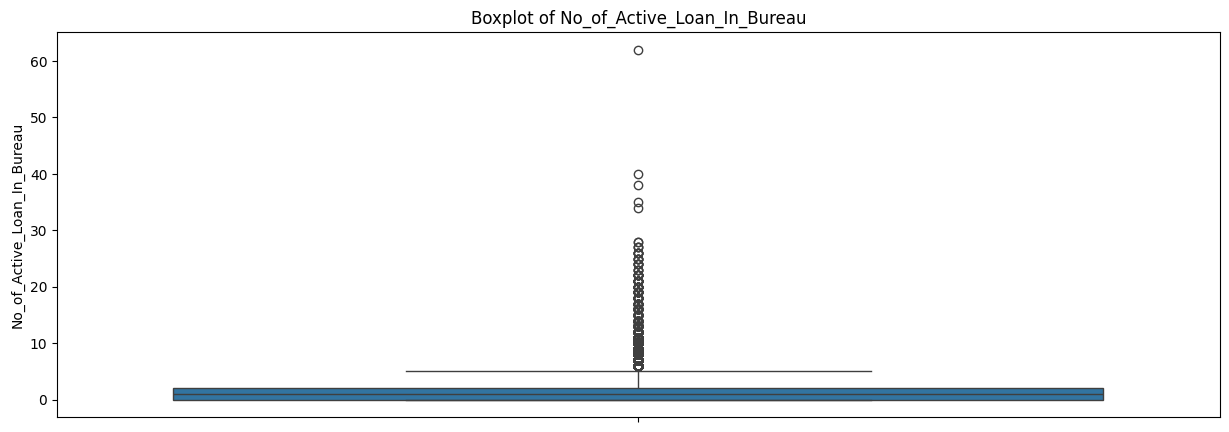

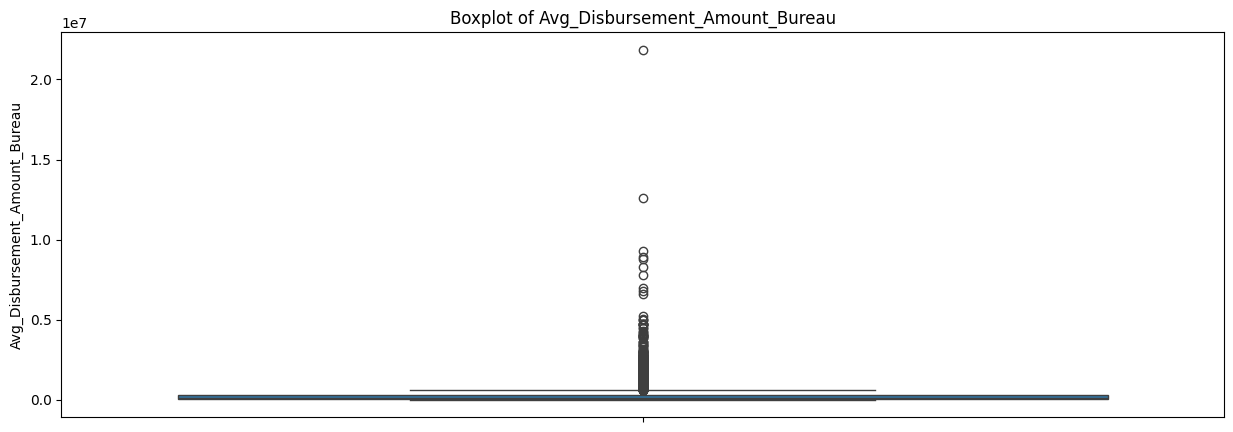

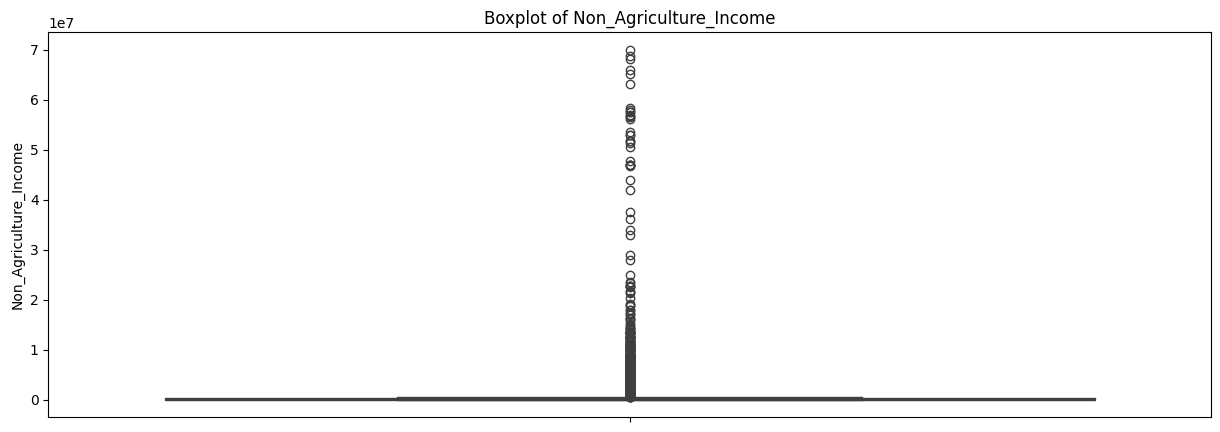

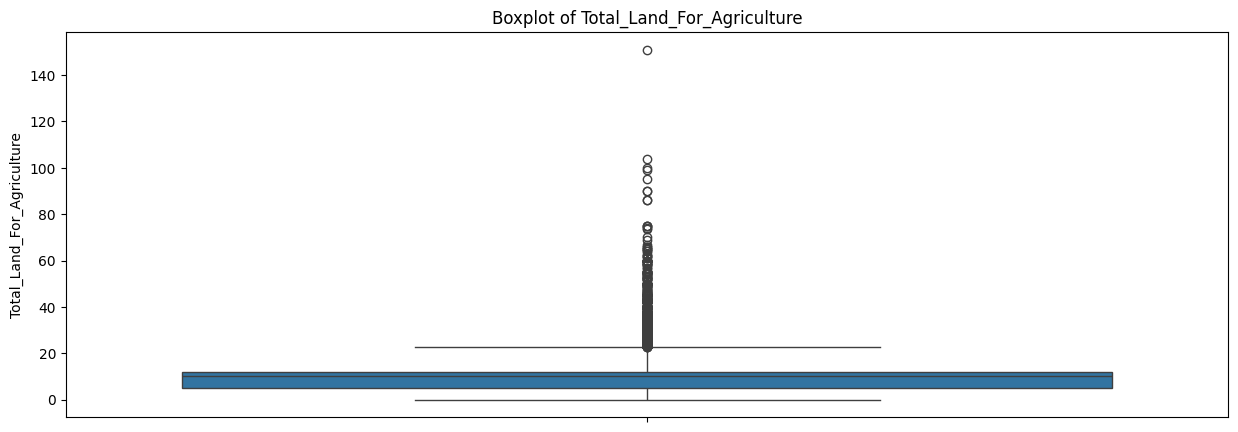

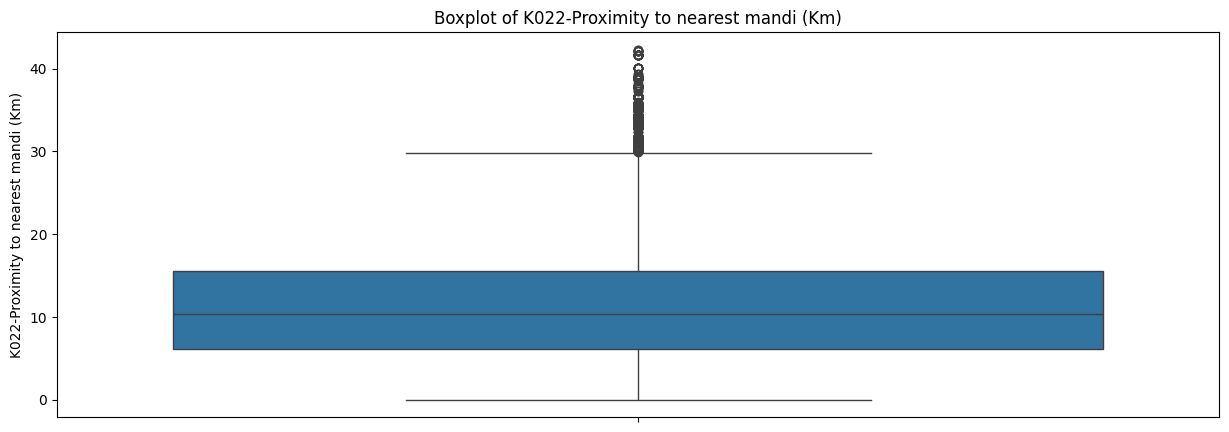

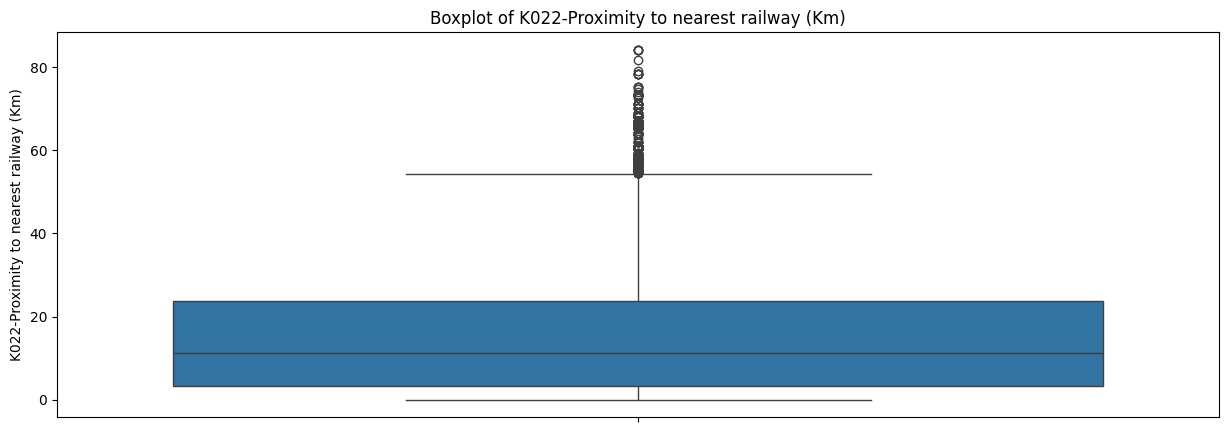

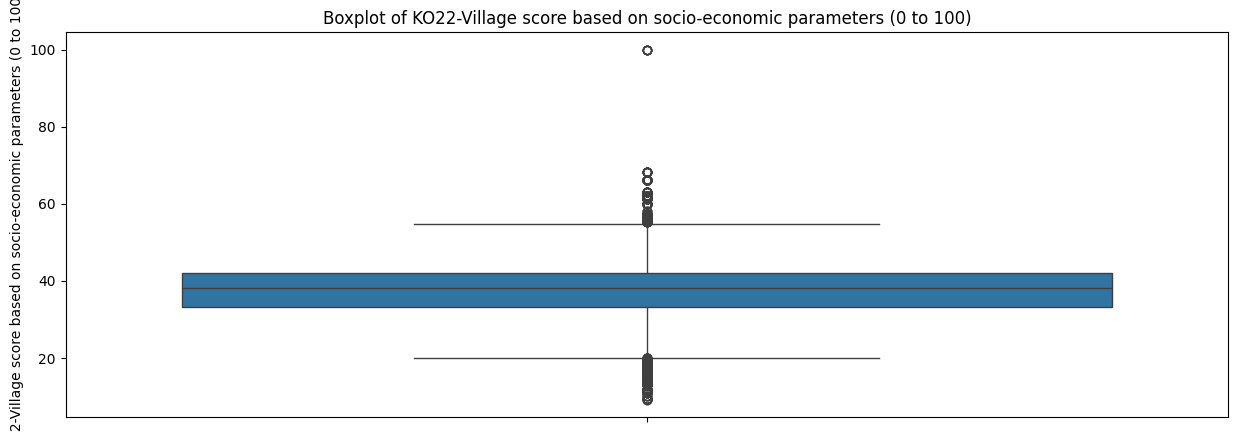

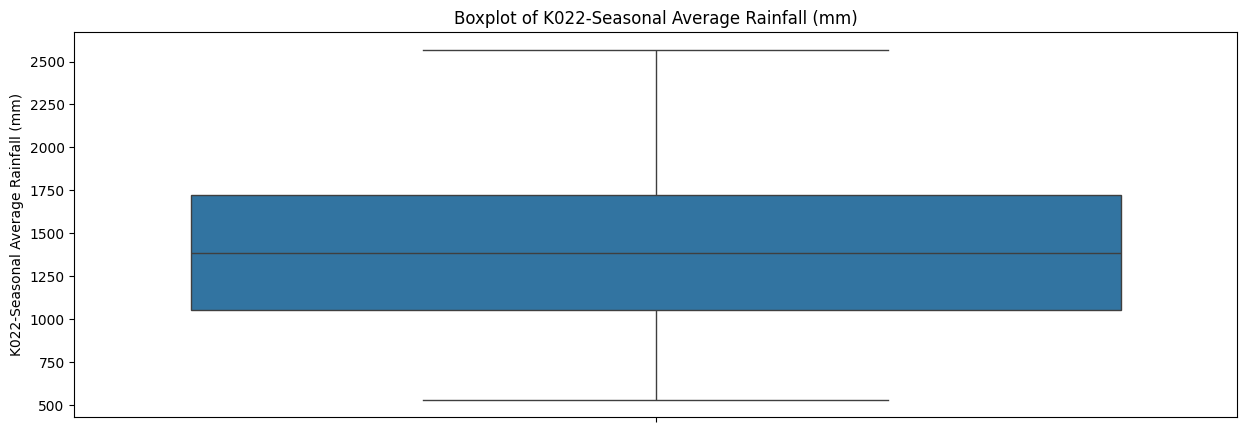

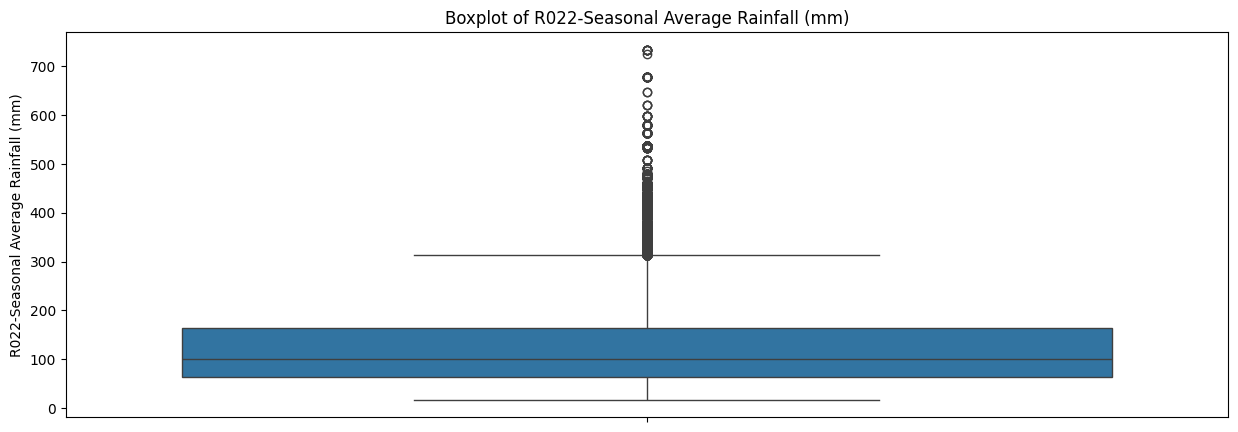

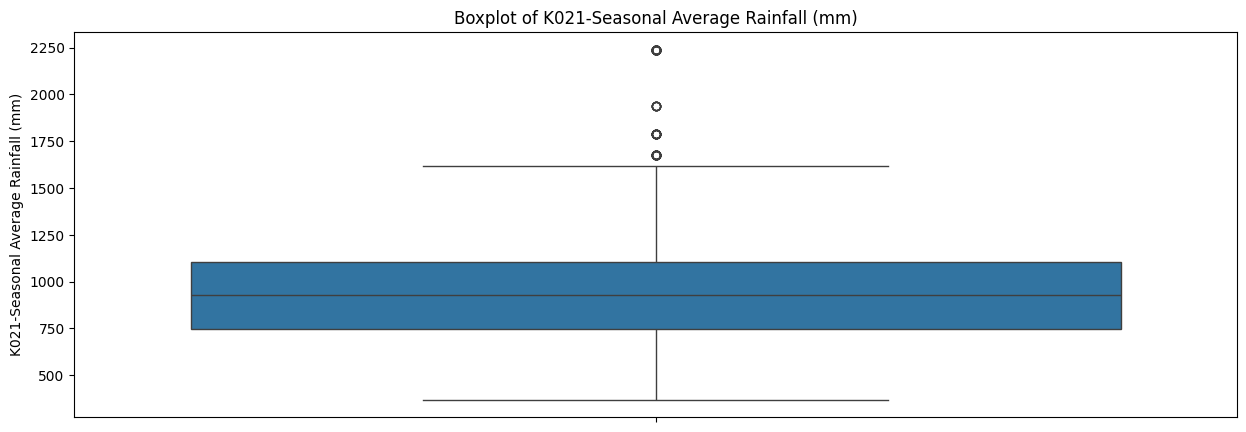

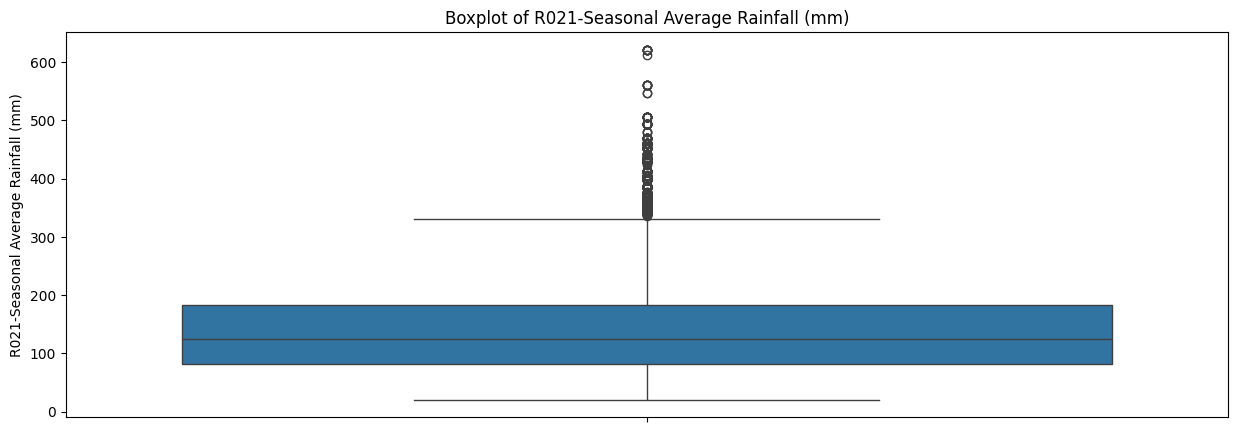

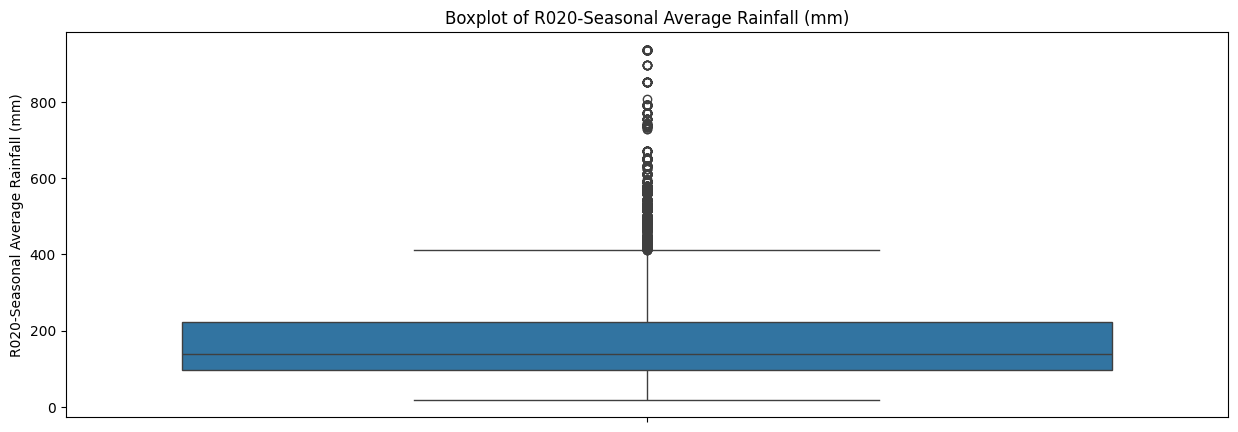

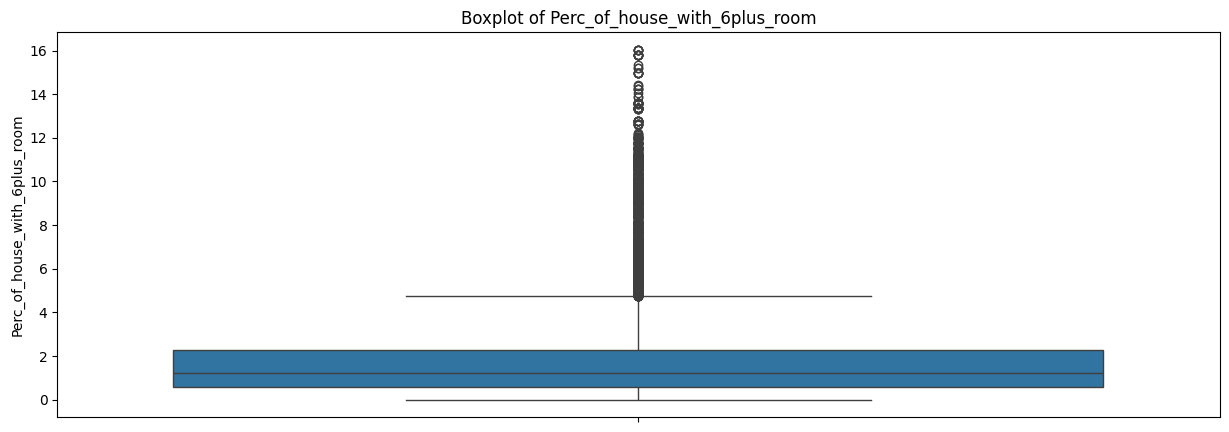

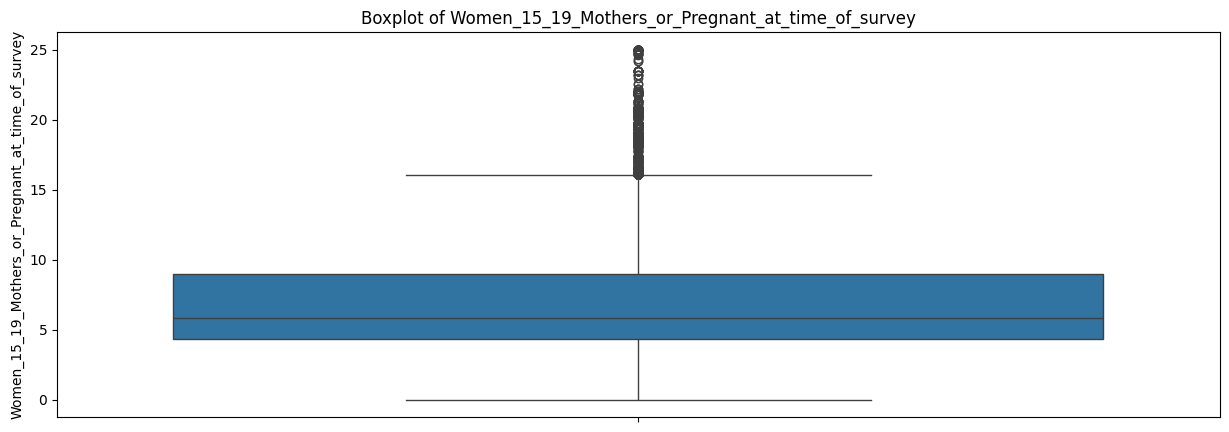

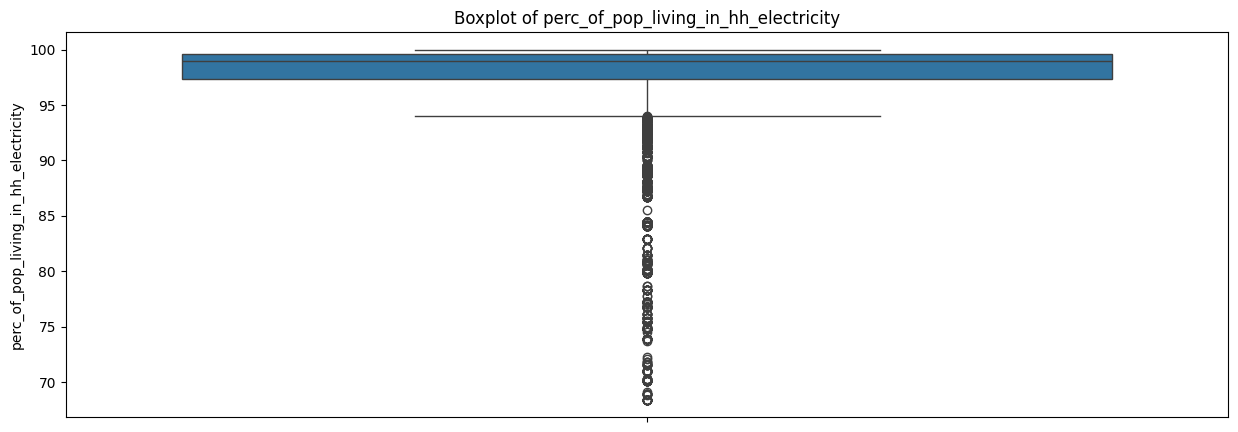

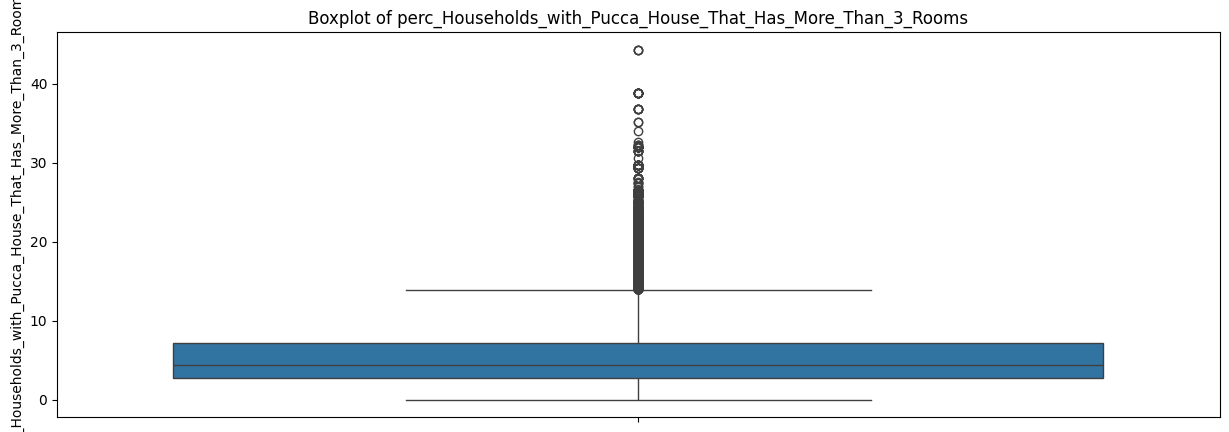

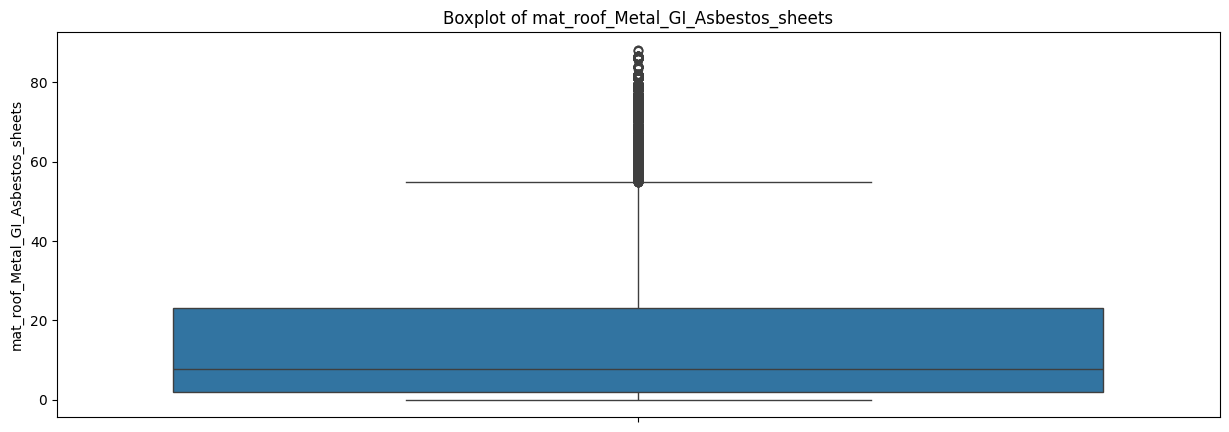

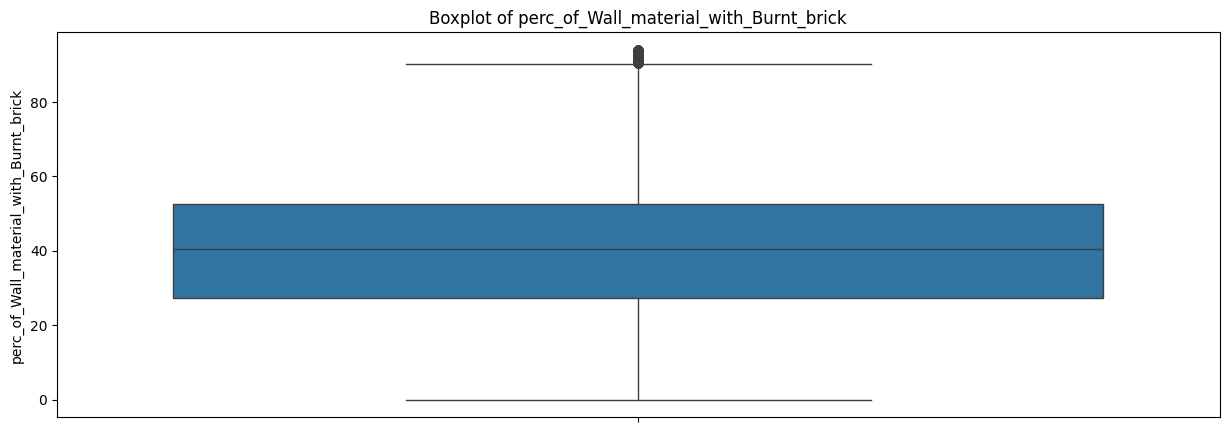

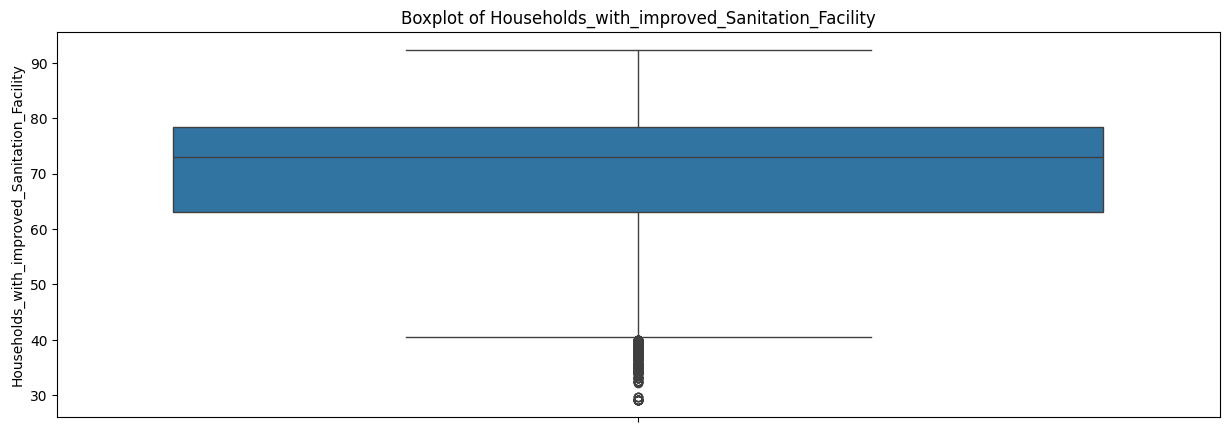

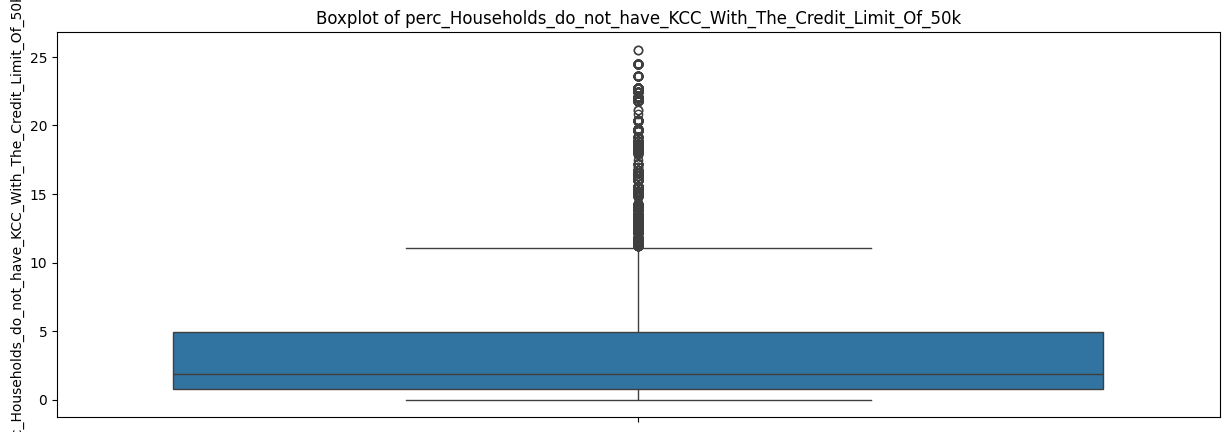

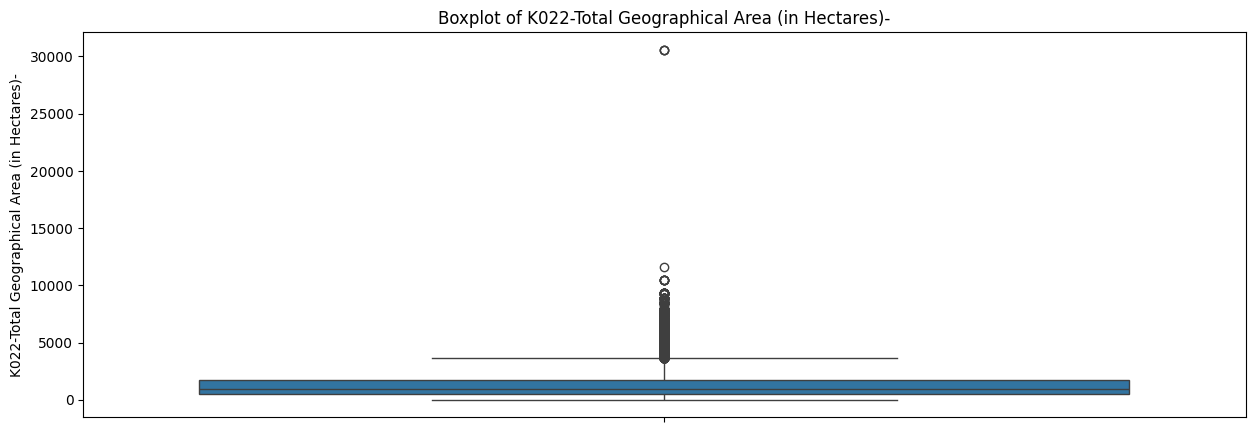

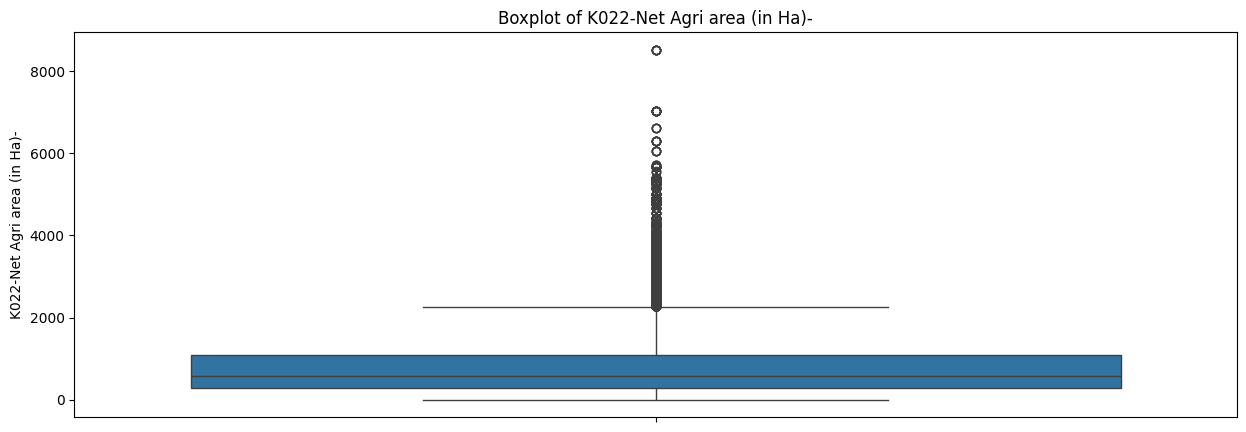

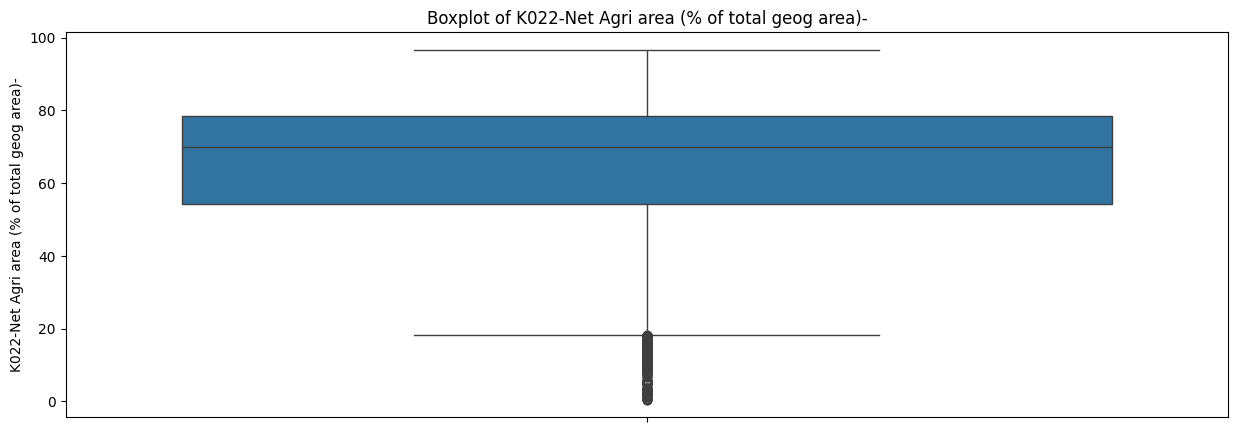

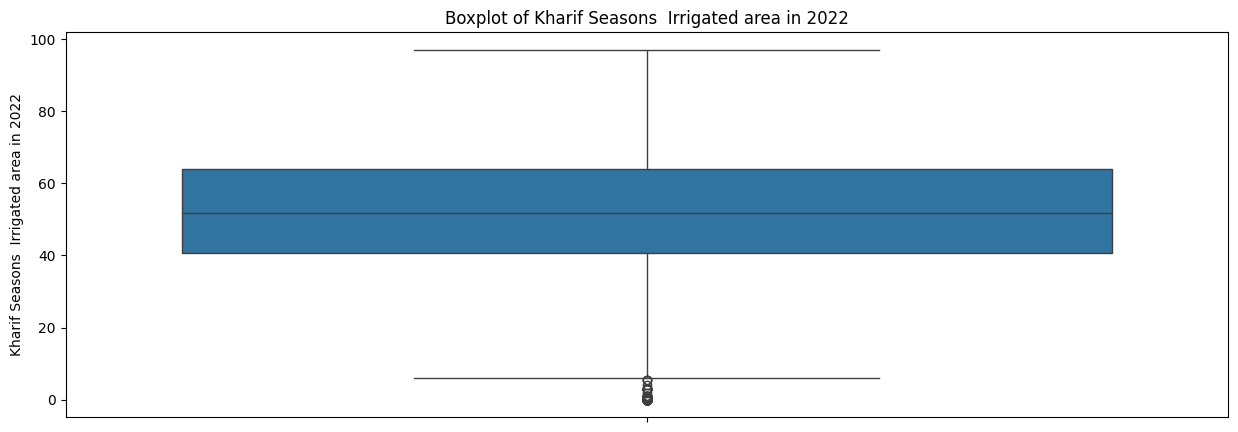

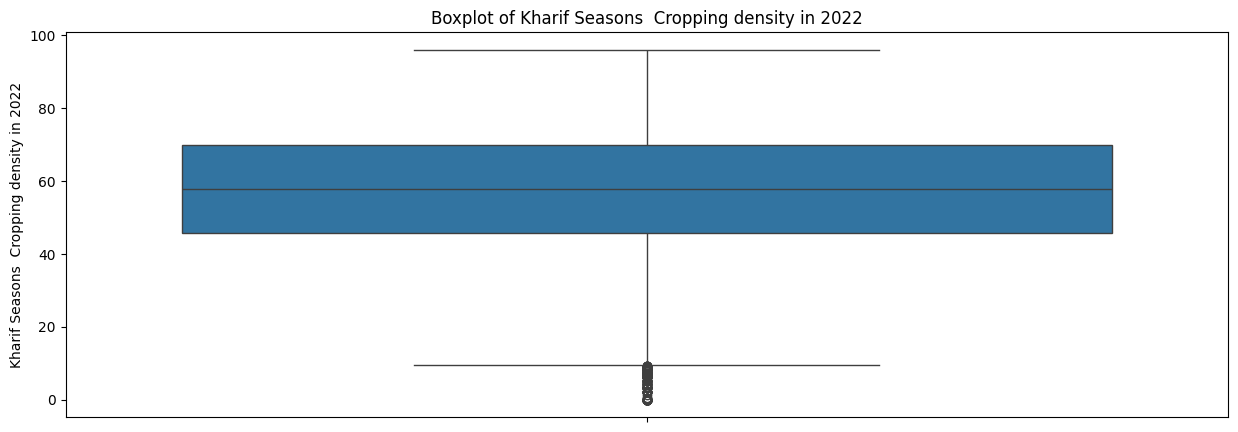

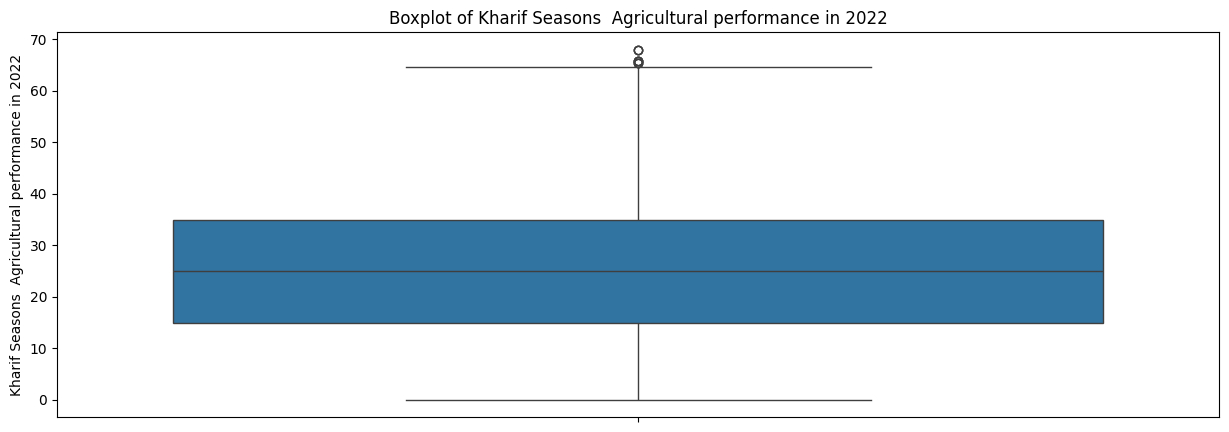

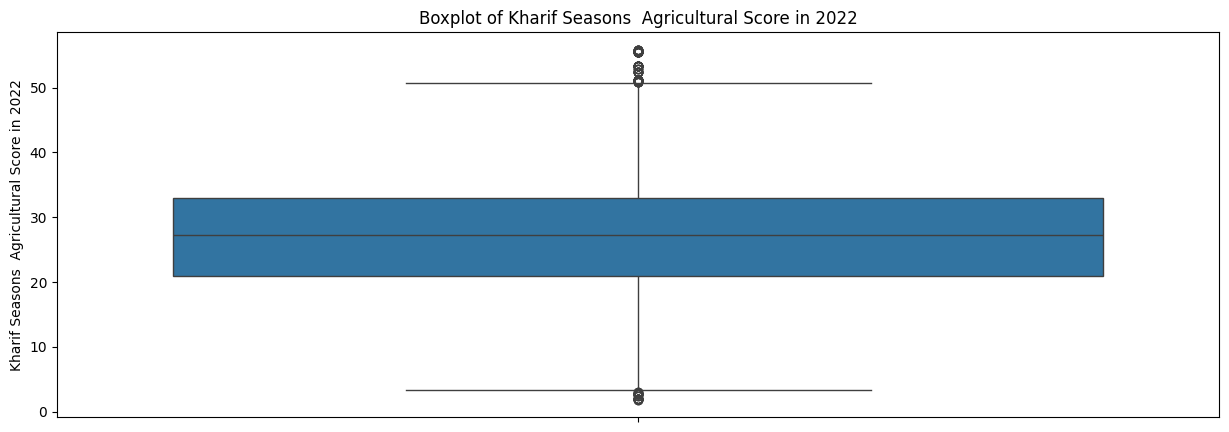

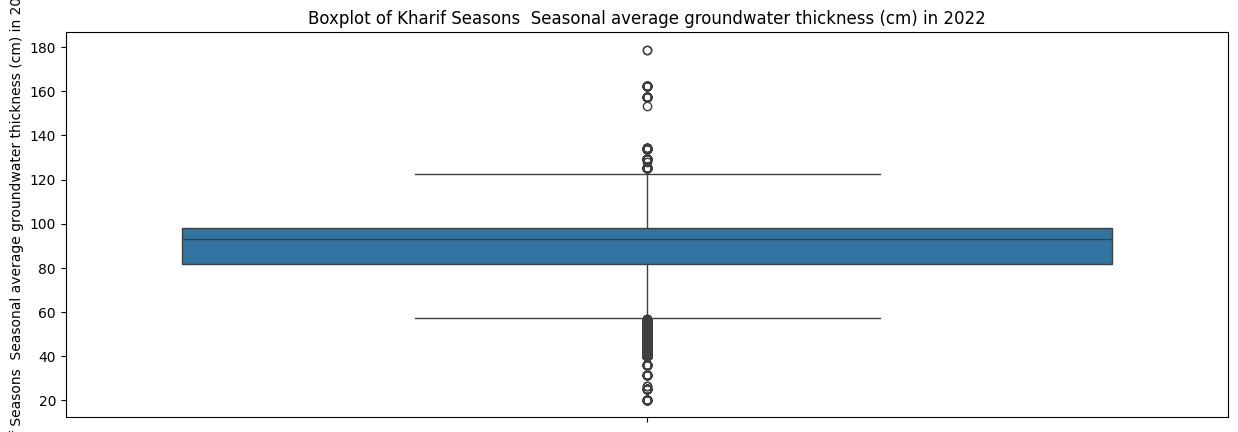

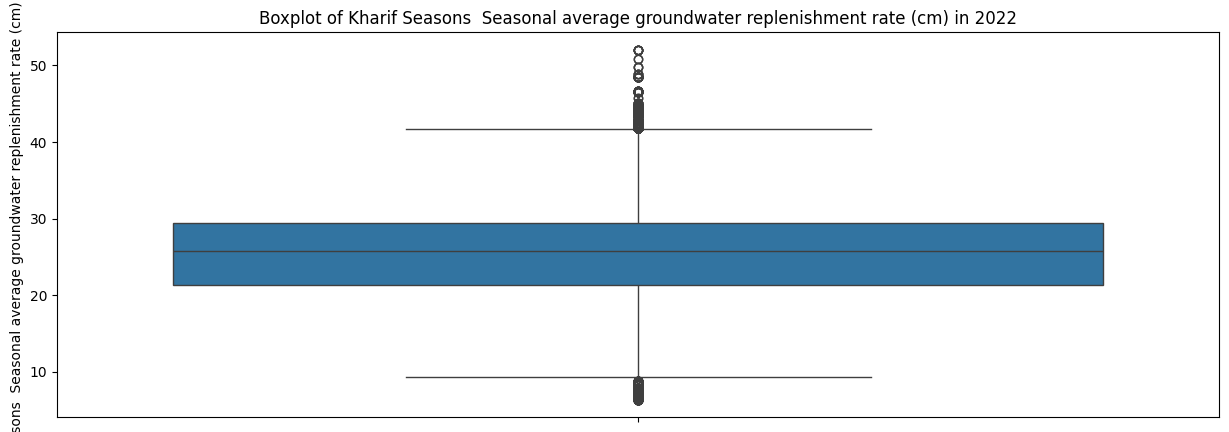

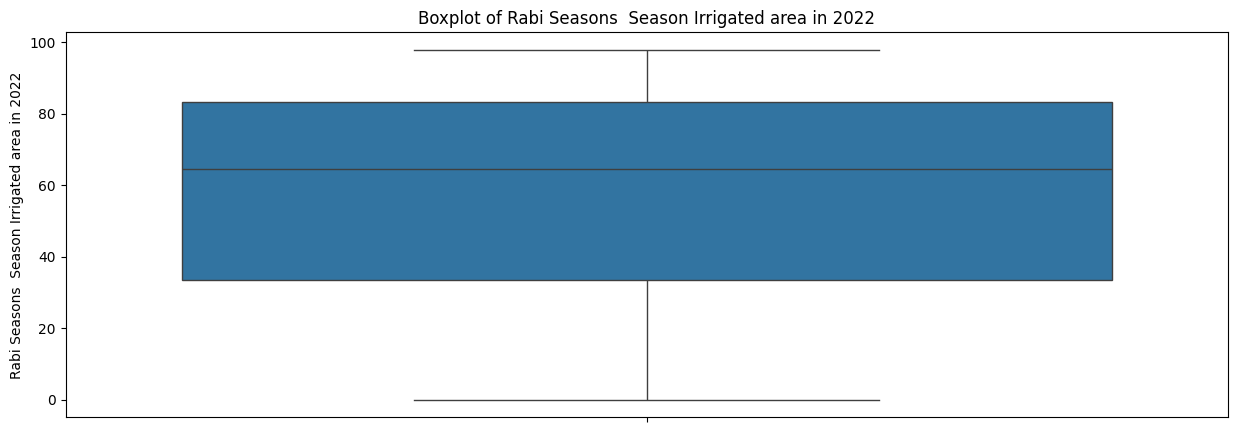

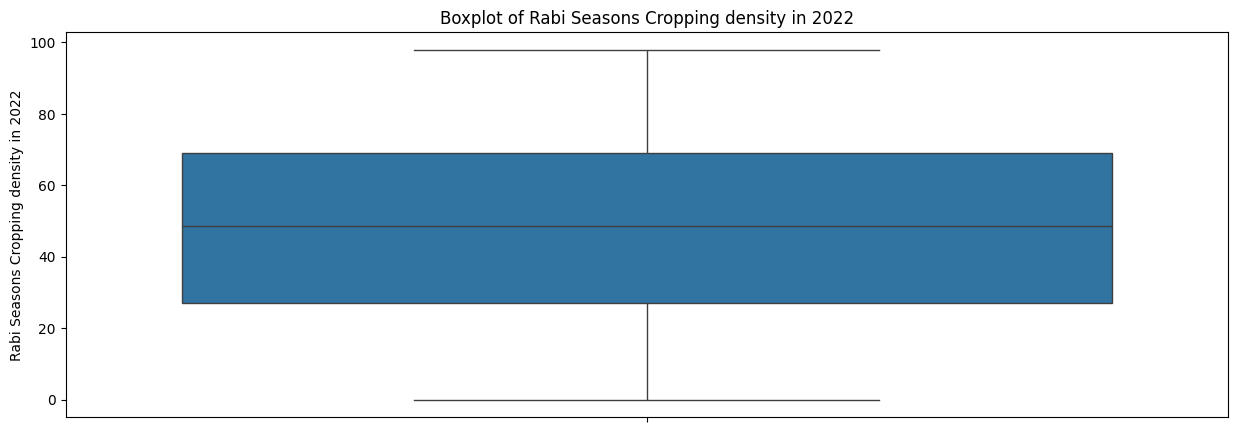

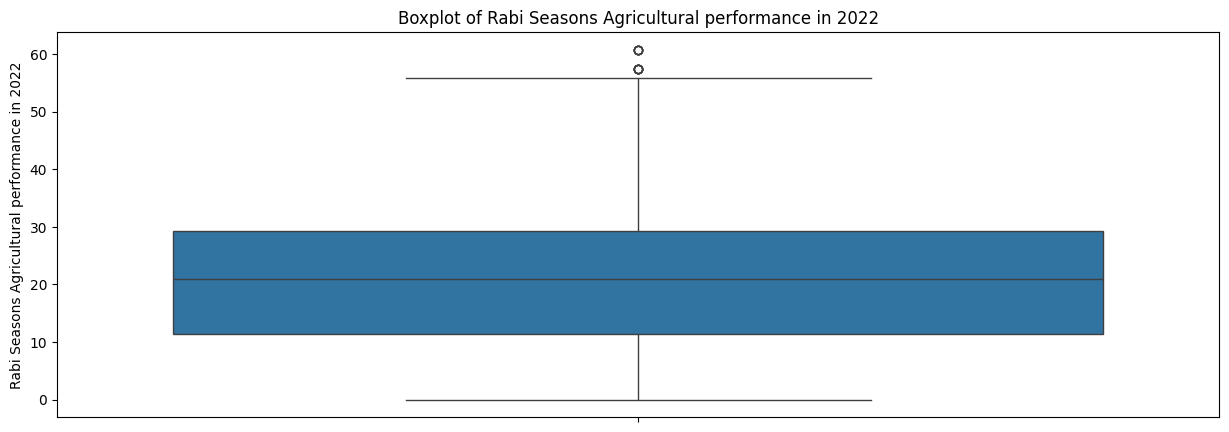

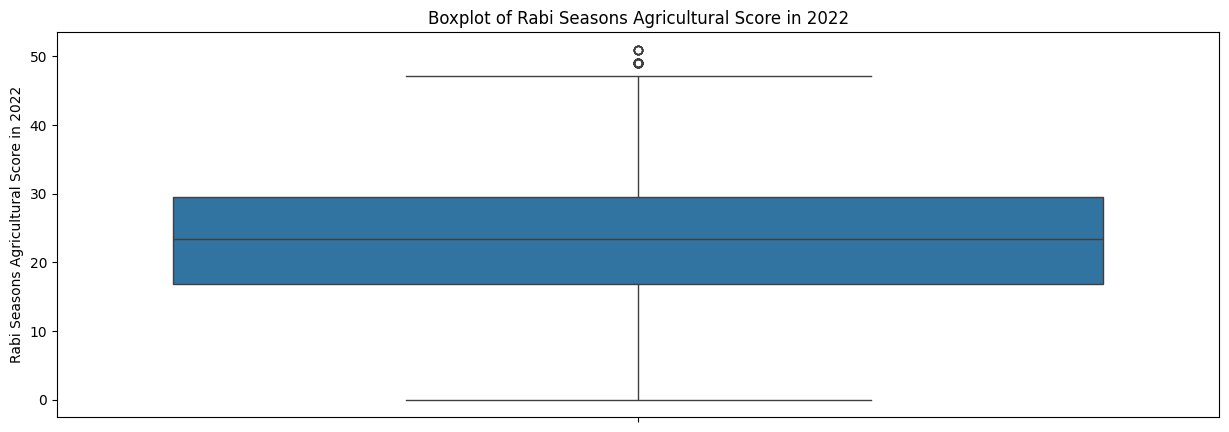

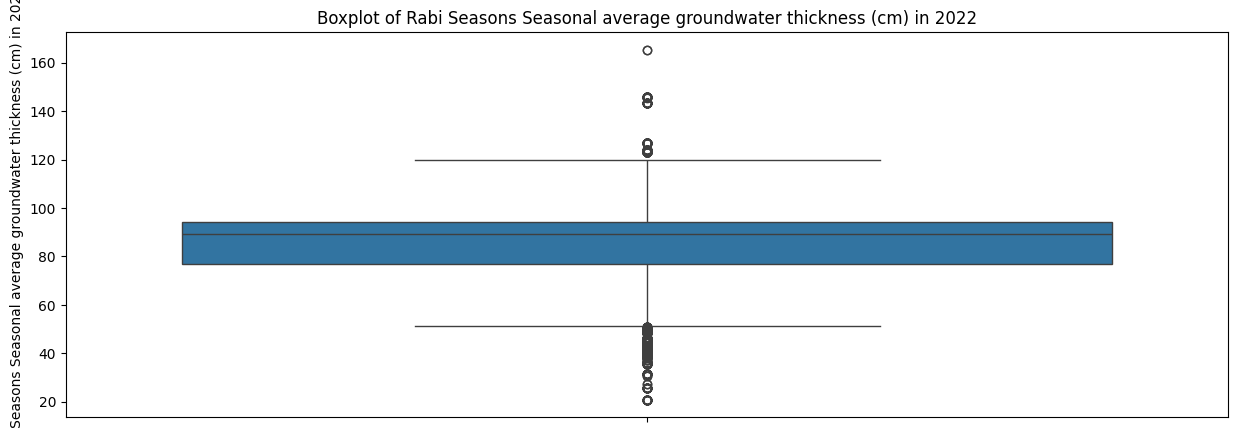

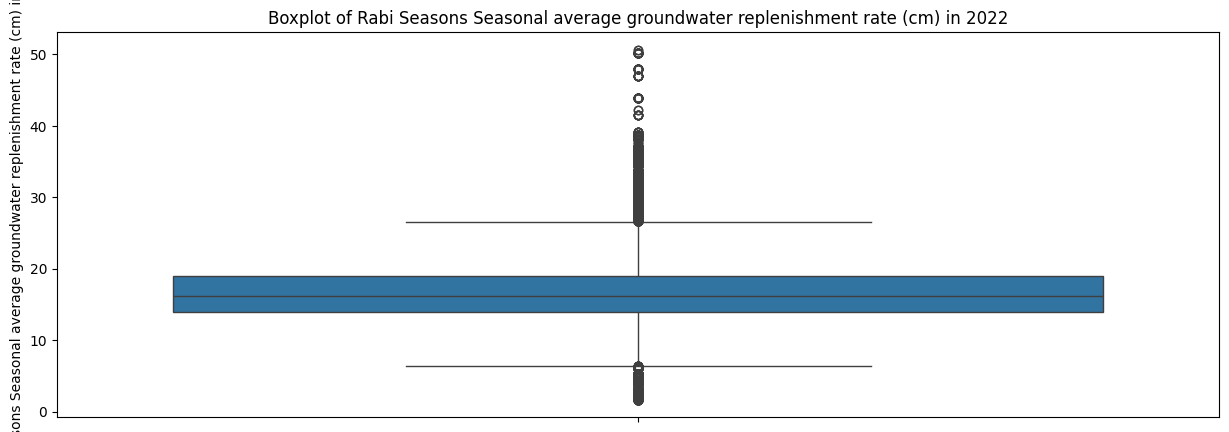

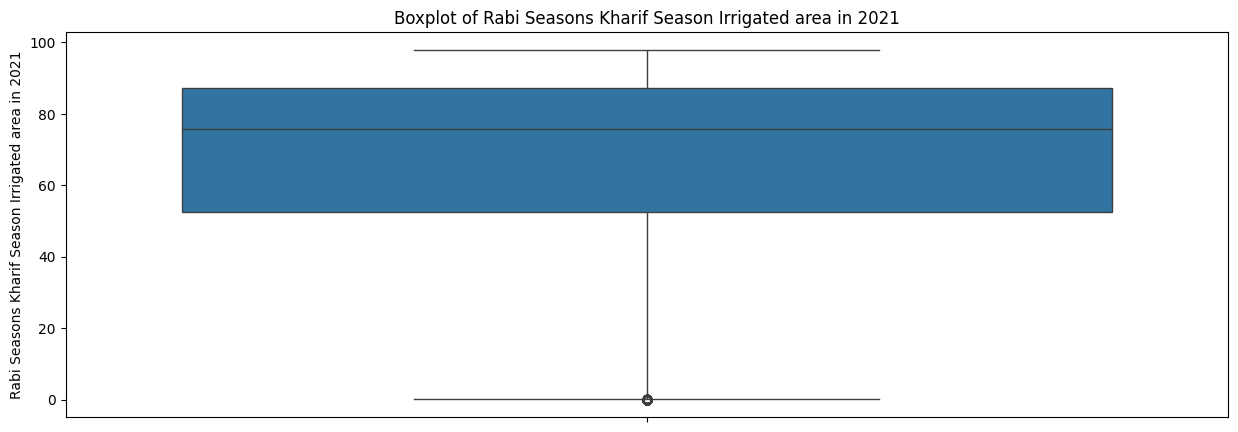

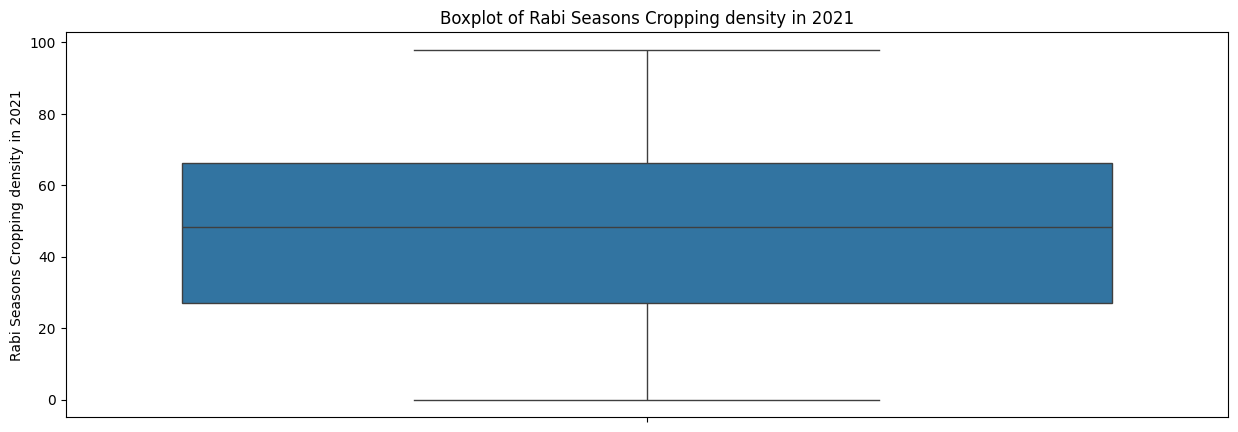

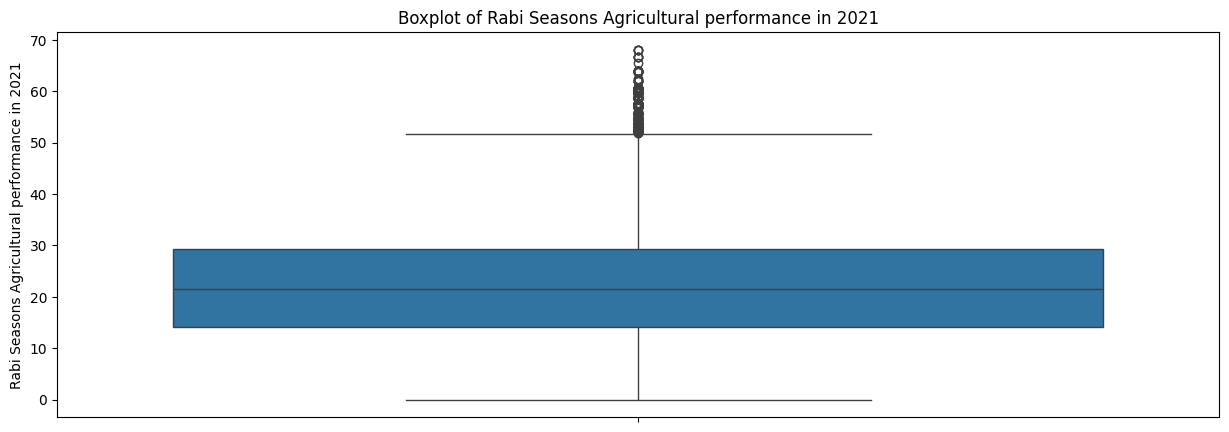

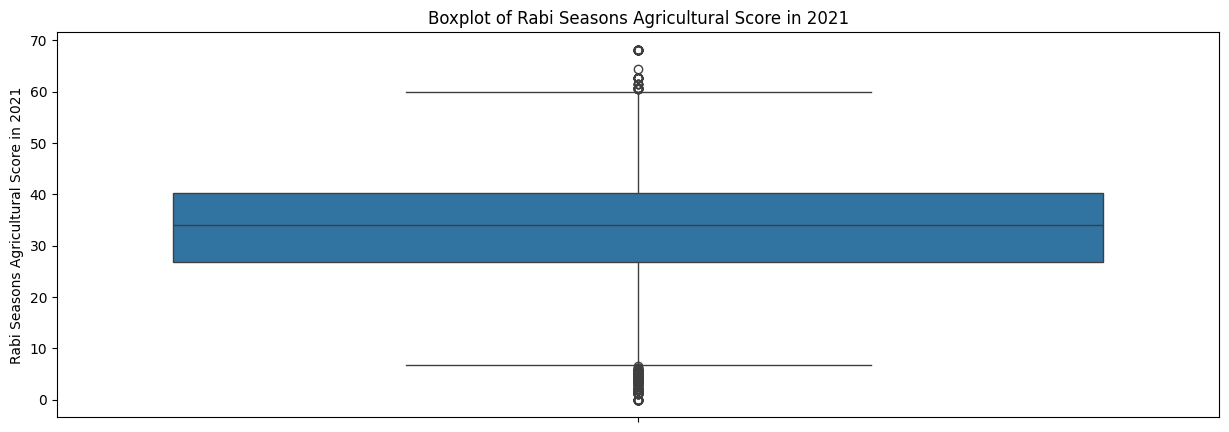

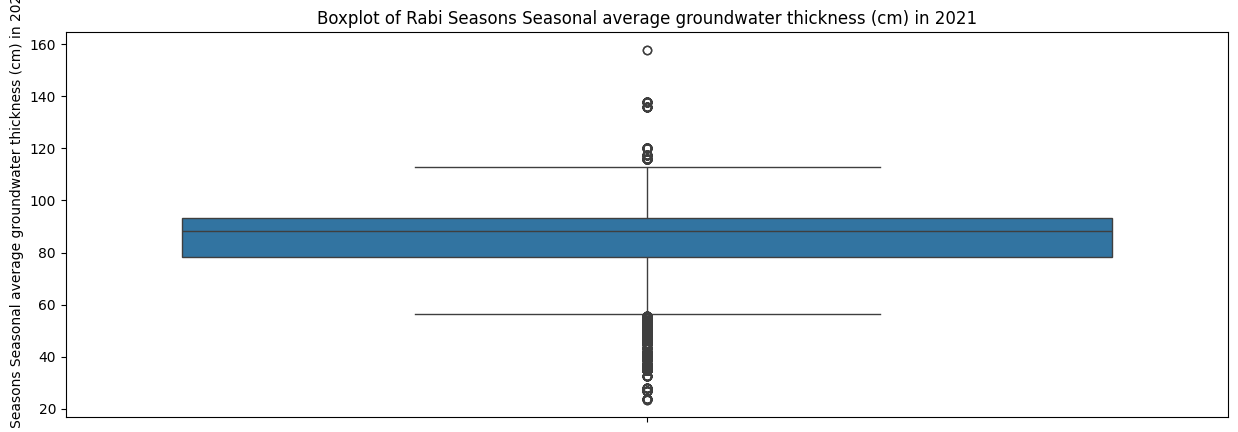

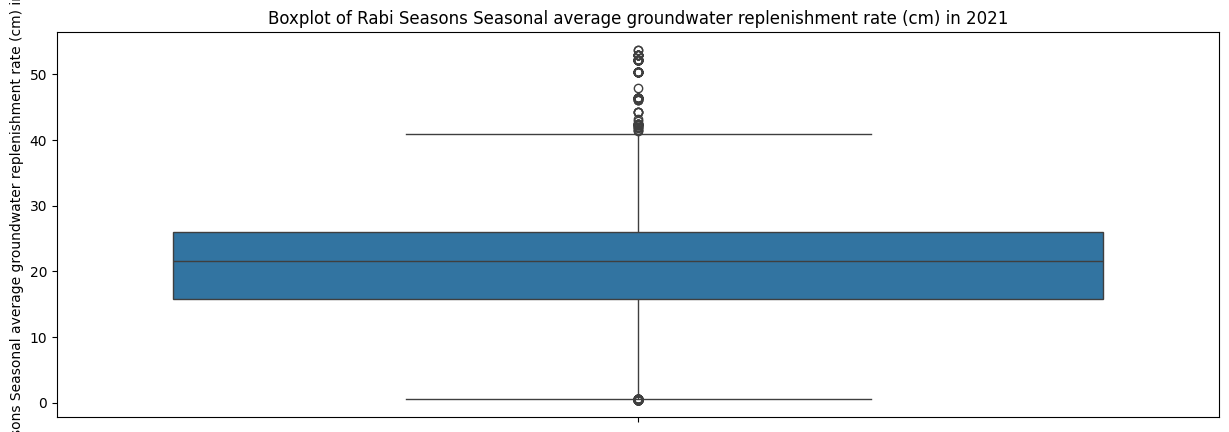

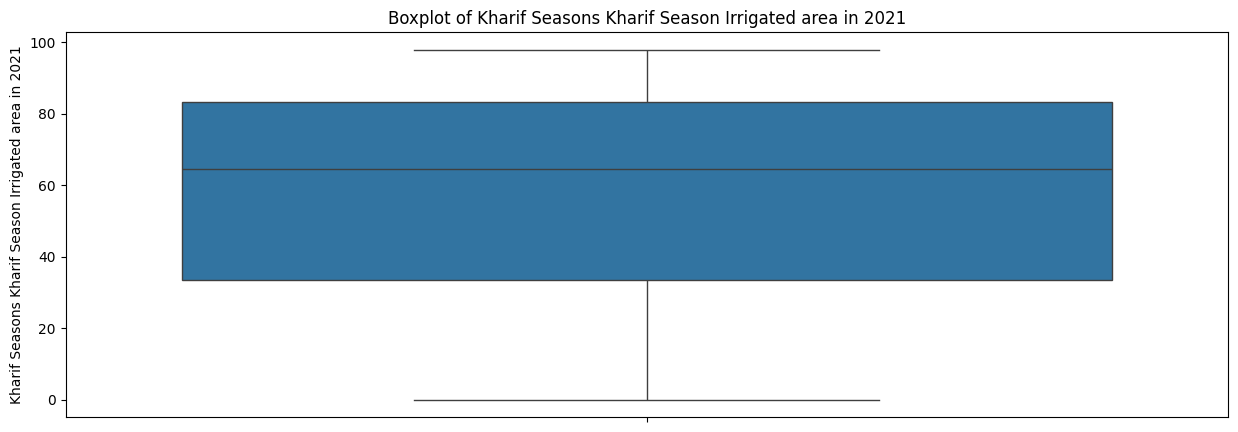

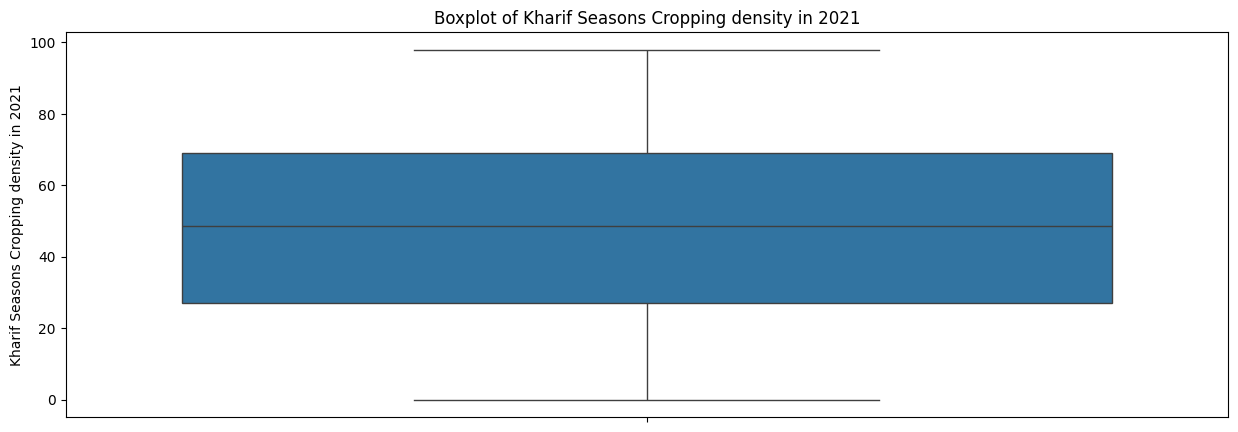

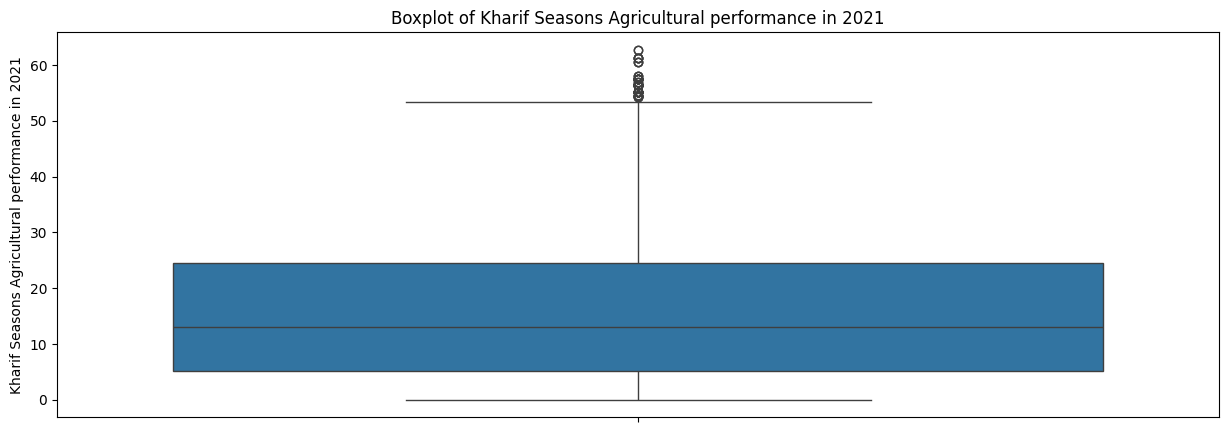

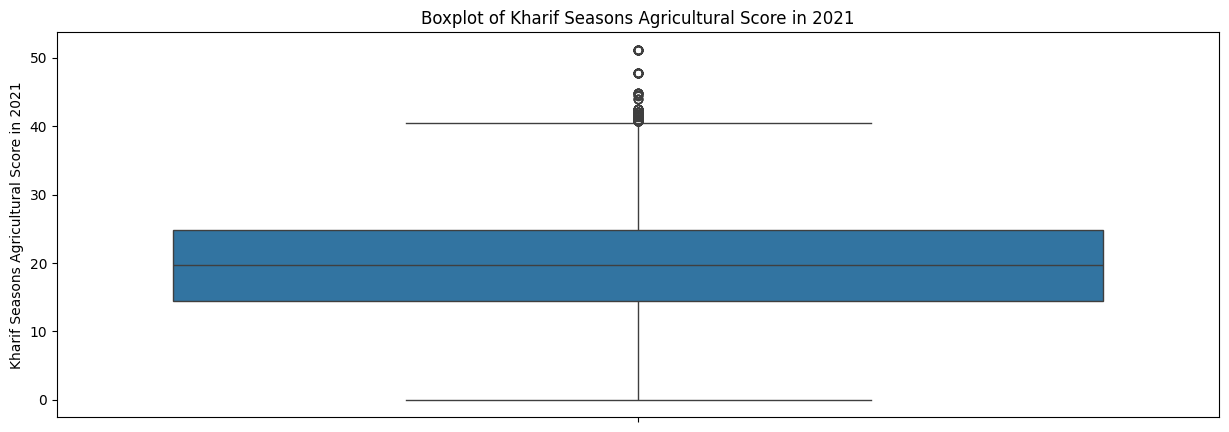

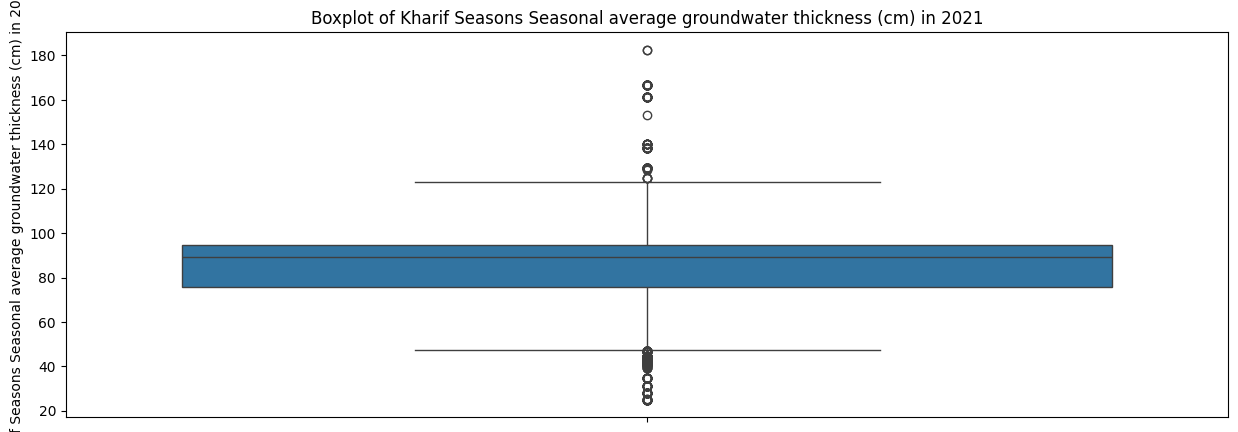

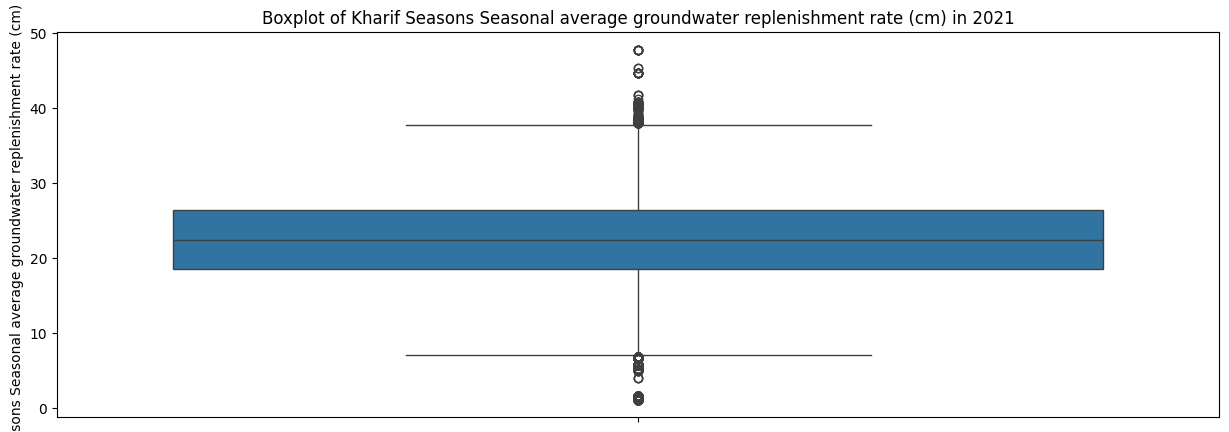

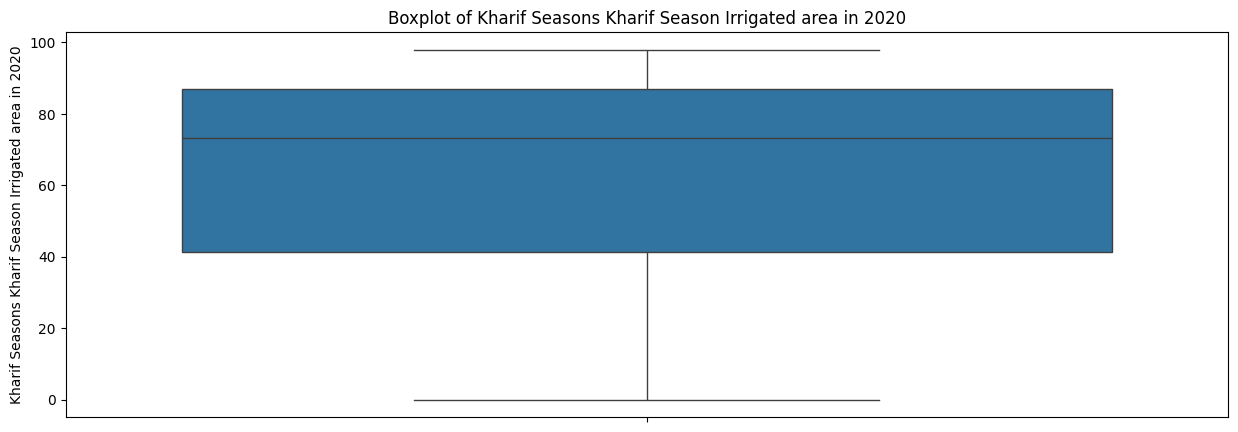

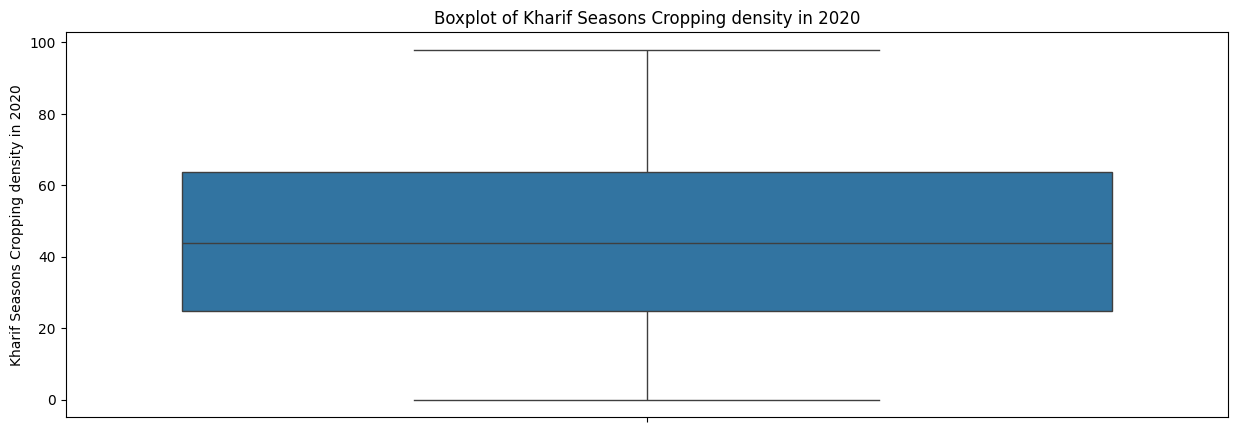

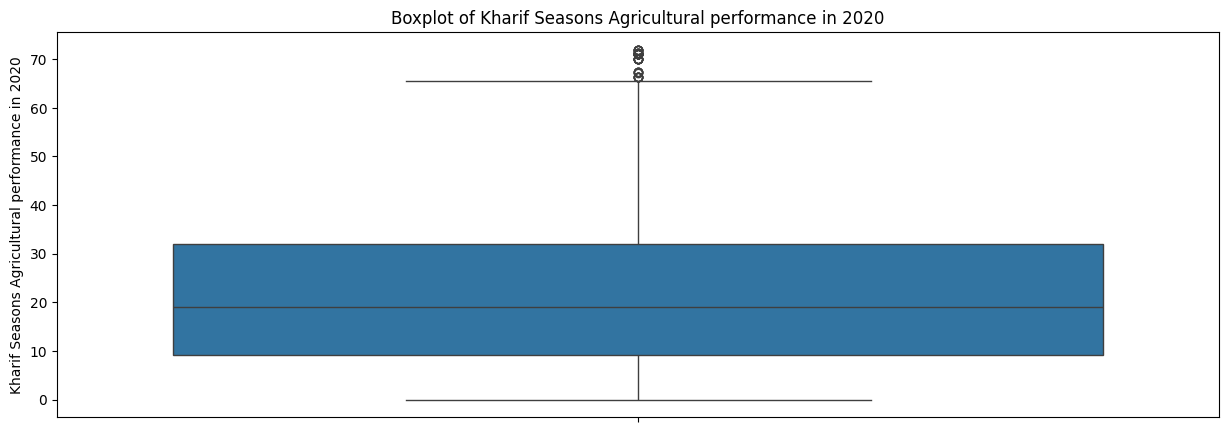

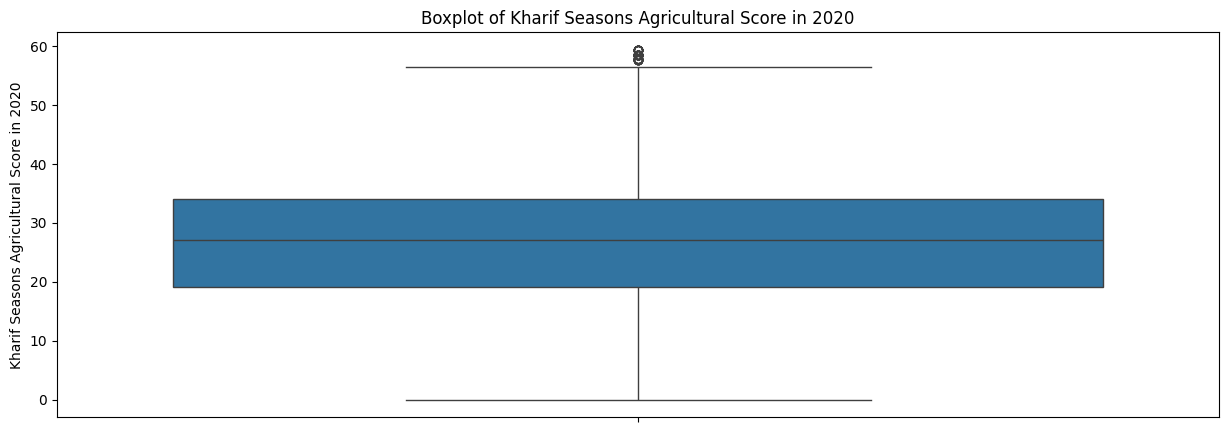

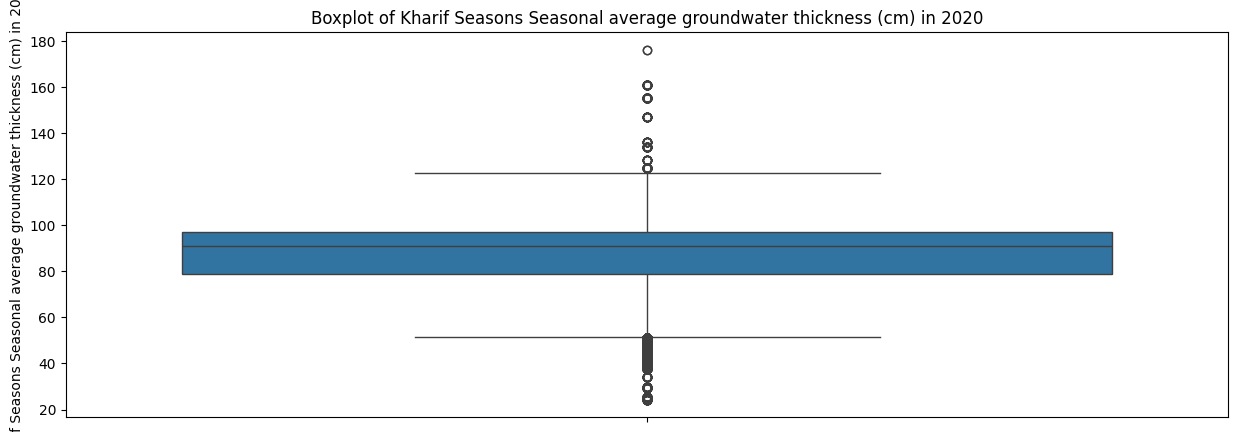

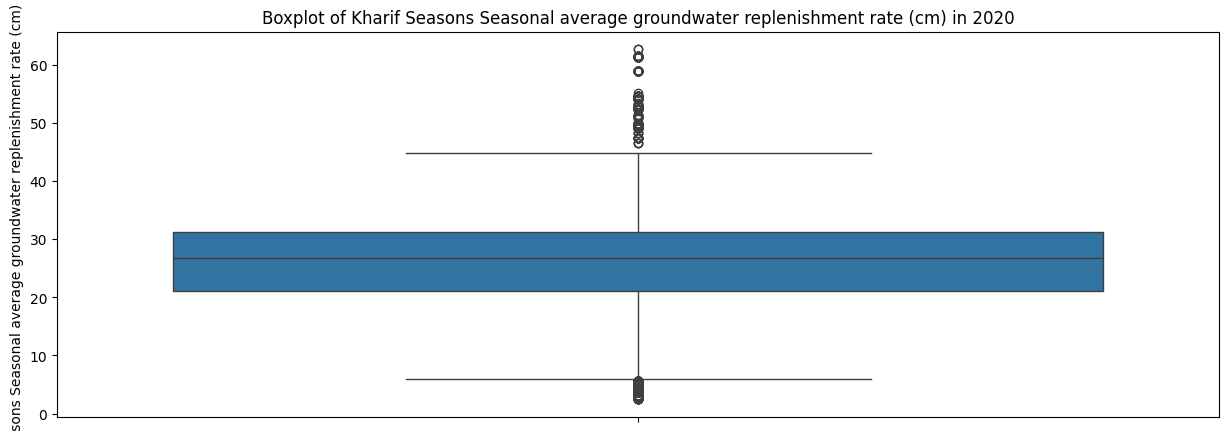

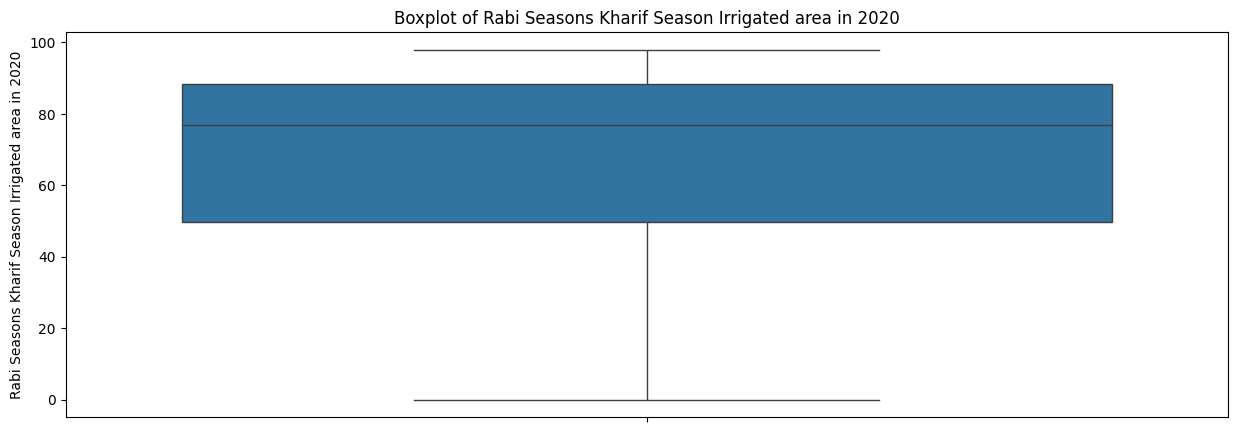

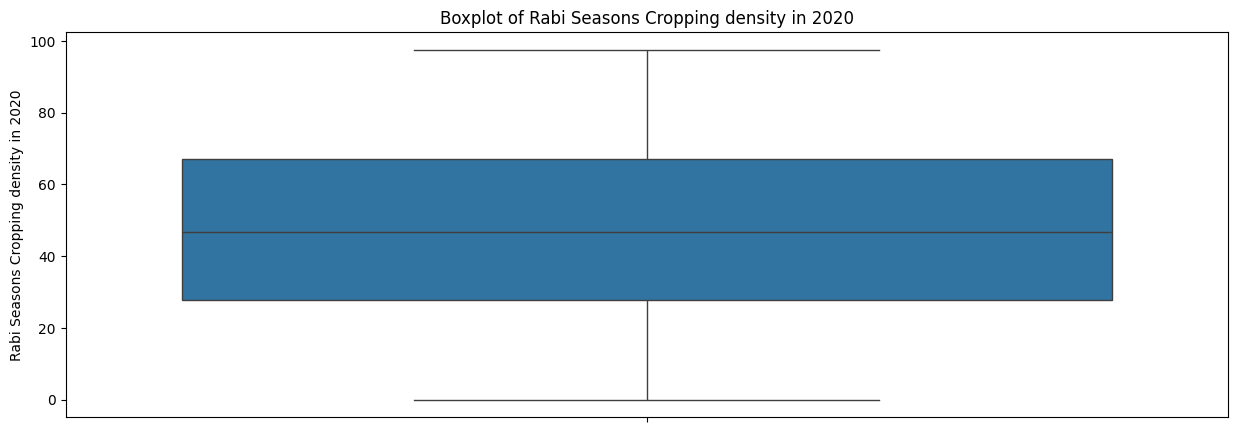

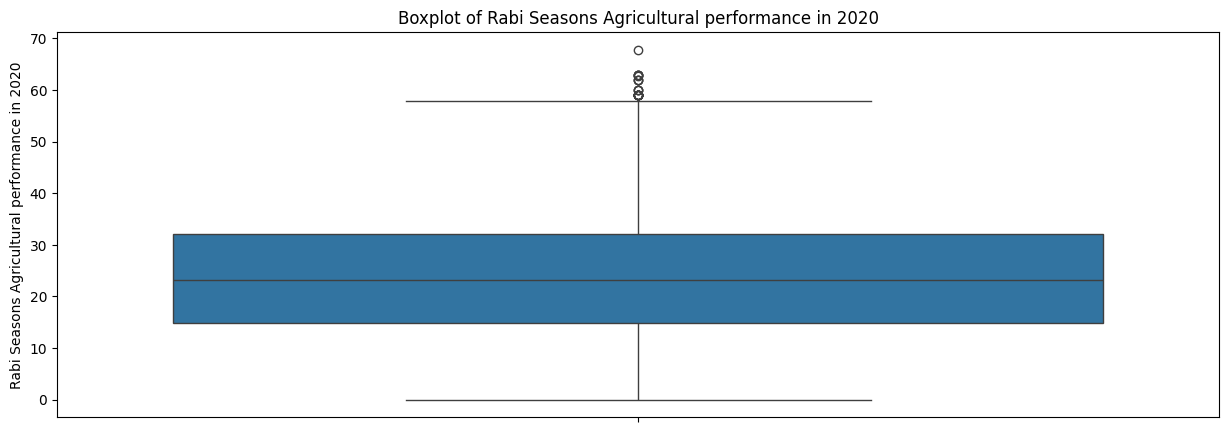

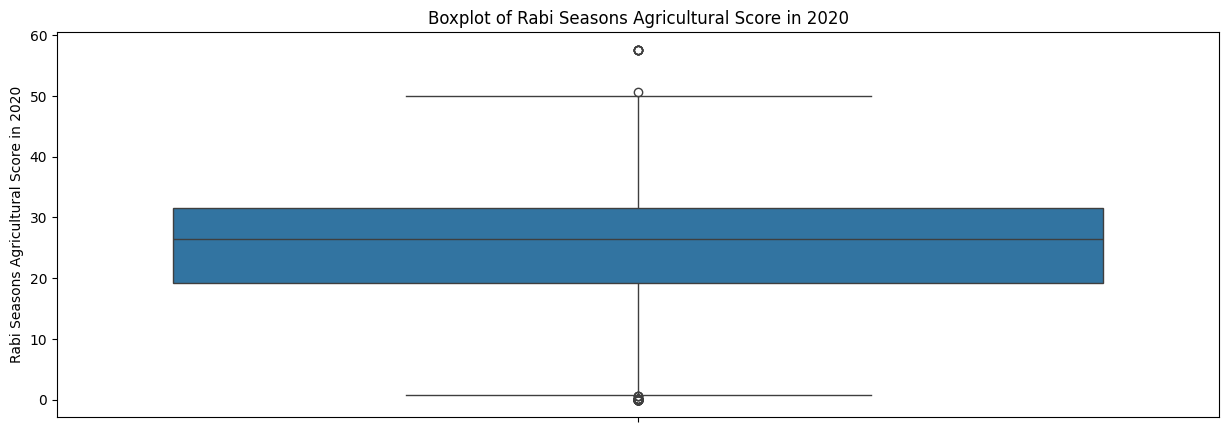

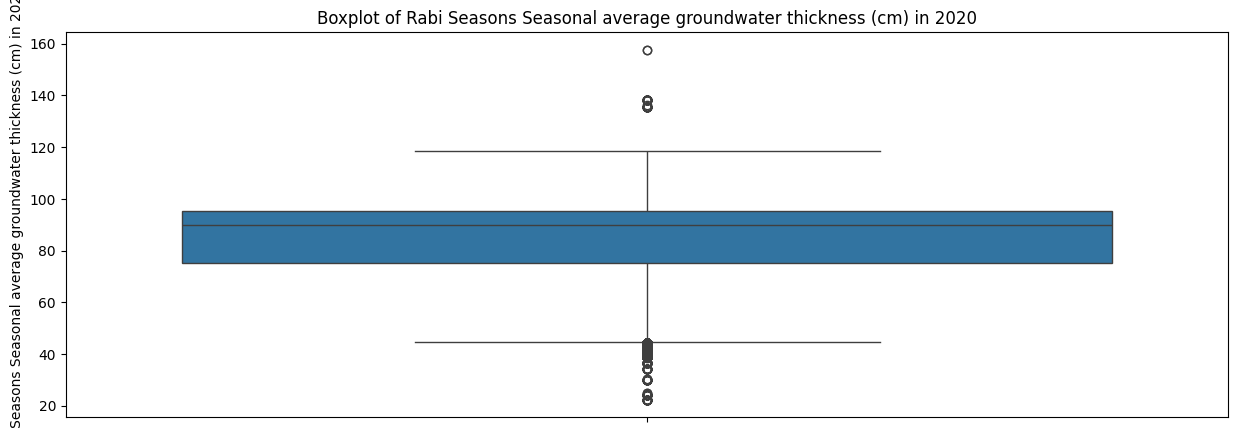

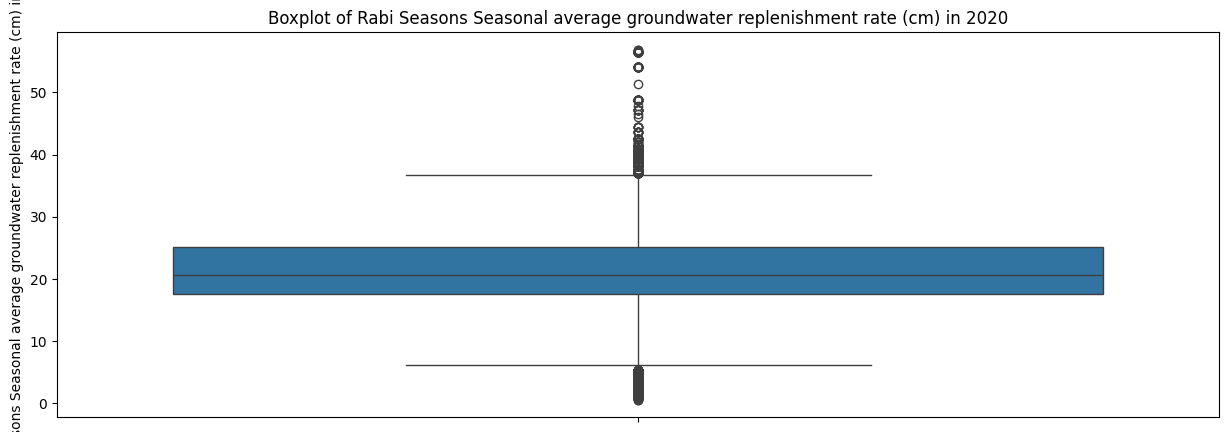

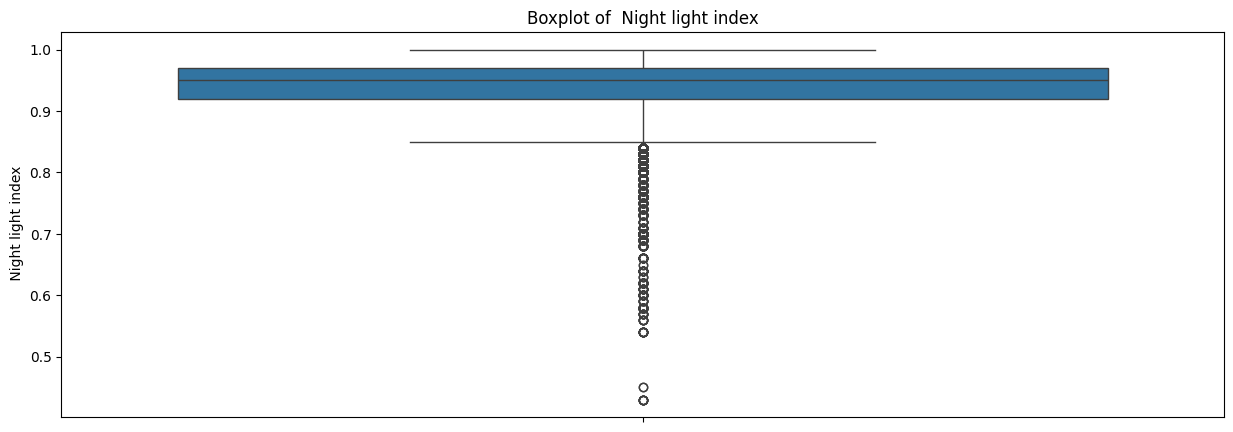

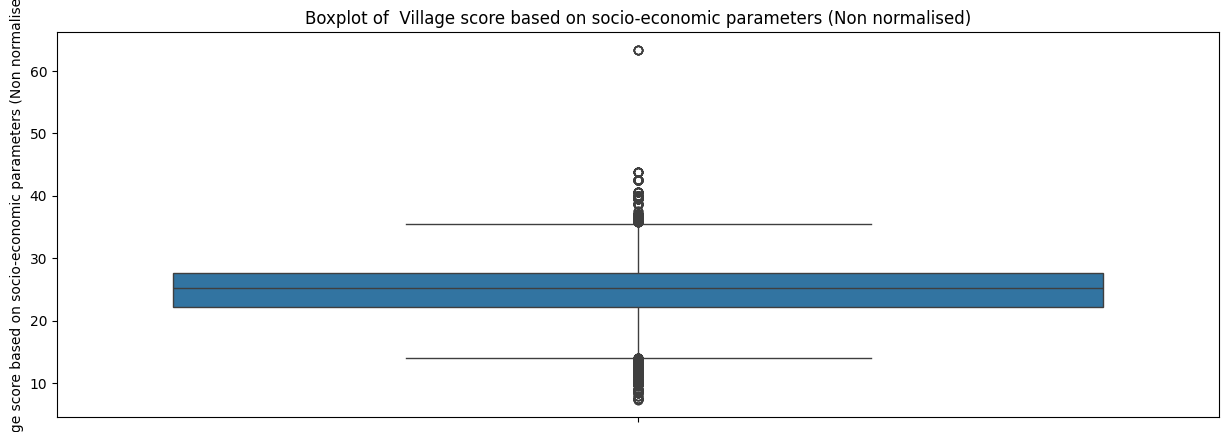

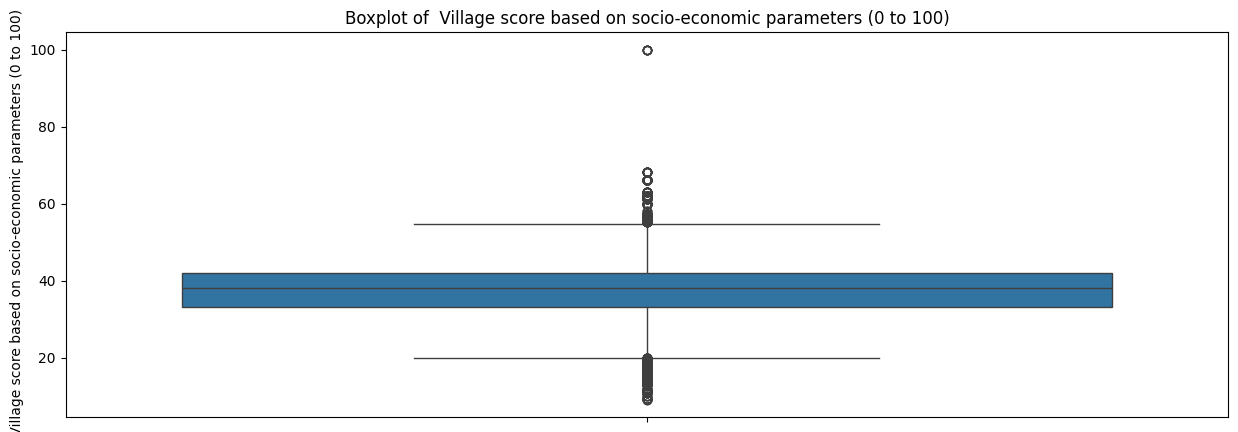

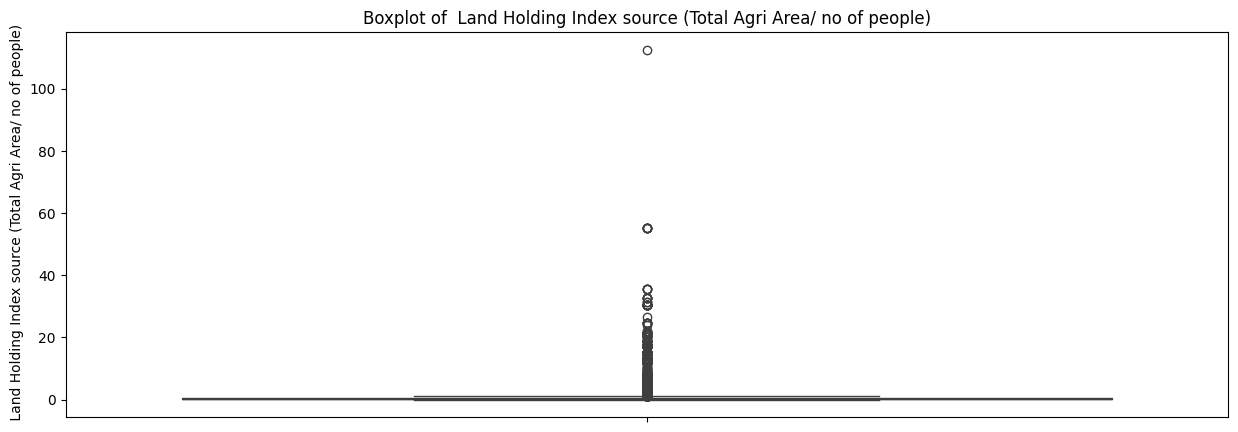

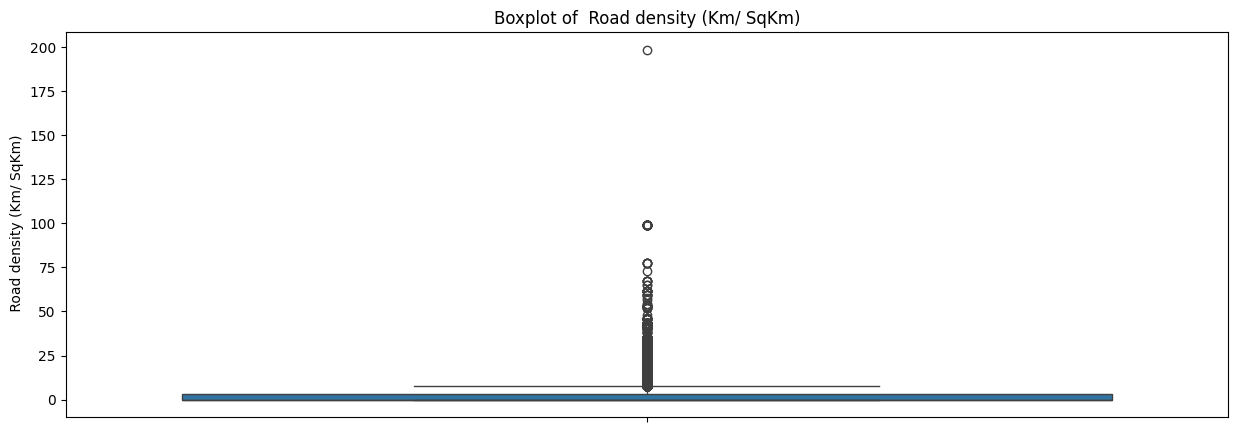

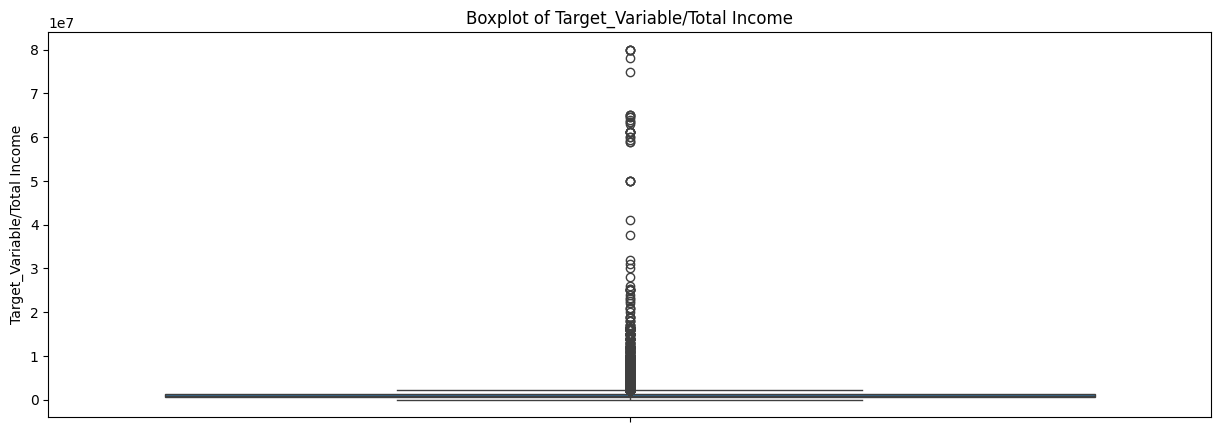

In [8]:
def plot_numeric_boxplots(df, figsize=(15, 5)):
    # Select only numeric columns
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    
    for col in numeric_cols:
        plt.figure(figsize=figsize)
        sns.boxplot(y=df[col])
        plt.title(f'Boxplot of {col}')
        plt.show()

plot_numeric_boxplots(df)

there are outliers a ot of them, so we need to fix that as well, in the post split processing

trying scatter plot now ton find the relation between target and columns

In [ ]:
def plot_numeric_scatter(df, target=None, figsize=(7, 5)):
    
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    numeric_cols = numeric_cols.drop(target)
    
    for col in numeric_cols:
        plt.figure(figsize=figsize)
        if target is None:
            # Just plot column vs index
            plt.scatter(df.index, df[col], alpha=0.6)
            plt.xlabel('Index')
            plt.ylabel(col)
            plt.title(f'Scatter plot of {col} vs Index')
        else:
            # Plot column vs target
            plt.scatter(df[col], df[target], alpha=0.6)
            plt.xlabel(col)
            plt.ylabel(target)
            plt.title(f'Scatter plot of {col} vs {target}')
        plt.show()
        
plot_numeric_scatter(df, target="Target_Variable/Total Income")

now ploting heatmap to unerstand correlation between data

In [ ]:
def plot_correlation_heatmap(df, target=None, figsize=(12,10), cmap='coolwarm'):
    # Select numeric columns
    numeric_cols = df.select_dtypes(include=['int64','float64']).columns
    
    # Include target if provided
    if target is not None and target in df.columns and target not in numeric_cols:
        numeric_cols = numeric_cols.append(pd.Index([target]))
    
    # Compute correlation matrix
    corr_matrix = df[numeric_cols].corr()
    
    # Plot heatmap
    plt.figure(figsize=figsize)
    sns.heatmap(corr_matrix, annot=False, fmt=".2f", cmap=cmap, square=True)
    plt.title("Correlation Heatmap")
    plt.show()
    
plot_correlation_heatmap(df, target="Target_Variable/Total Income")

from this correlation matrix, we can now first remove the multicollinear features which have high relation, and keep the once which are more related to target, after that we remove those which have nearly zero collinearity with the target

NOW WE WILL START POST SPLIT PROCESSING

In [ ]:
# this is a 70 20 10 split, train, validation, test
X = df.drop(columns=["Target_Variable/Total Income"])
y = df["Target_Variable/Total Income"]

# First split → test set (10%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.10, random_state=0
)

# Second split → validation set (20% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=0
)


# finally, X_train, X_val, X_test, and y_train, y_val, y_test
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

Preprocessing after splitting
Imputation done
outlier remove ahan
scaling jatin
encoding me 
feature selection
handling imbalance
drop less correlated columns
now lets start post processing

In [ ]:
missing_cols = df.isna().sum()
missing_cols = missing_cols[missing_cols > 0]

print(missing_cols)

TO tell which distribution are normal and whic are skewed

In [ ]:
def detect_distribution(df, threshold=0.5):
    
    # automatically select numeric columns
    numeric_cols = df.select_dtypes(include=['number']).columns
    
    distribution_dict = {}

    for col in numeric_cols:
        skew_value = df[col].skew()

        if abs(skew_value) <= threshold:
            distribution_dict[col] = "normal"
        else:
            distribution_dict[col] = "skewed"

    return distribution_dict

OUTLIER REMOVER

In [ ]:
class OutlierRemover(BaseEstimator, TransformerMixin):
    def __init__(self, distribution_dict=None, z_thresh=3, iqr_multiplier=1.5, verbose=False):
        self.distribution_dict = distribution_dict
        self.z_thresh = z_thresh
        self.iqr_multiplier = iqr_multiplier
        self.bounds = {}
        self.verbose = verbose

    def fit(self, X, y=None):
        X = X.select_dtypes(include=np.number)
        if self.distribution_dict is None:
            self.distribution_dict = {}
            for col in X.columns:
                skew_value = X[col].skew()
                self.distribution_dict[col] = 'normal' if abs(skew_value) <= 0.5 else 'skewed'

        for col, dist_type in self.distribution_dict.items():
            if dist_type == "normal":
                mean = X[col].mean()
                std = X[col].std()
                lower = mean - self.z_thresh * std
                upper = mean + self.z_thresh * std
            elif dist_type == "skewed":
                Q1 = X[col].quantile(0.25)
                Q3 = X[col].quantile(0.75)
                IQR = Q3 - Q1
                lower = Q1 - self.iqr_multiplier * IQR
                upper = Q3 + self.iqr_multiplier * IQR
            self.bounds[col] = (lower, upper)
        return self

    def transform(self, X):
        X = X.copy()
        for col, (lower, upper) in self.bounds.items():
            if self.verbose:
                print(f"{col}: clipped {((X[col]<lower)|(X[col]>upper)).sum()} values")
            X[col] = X[col].clip(lower, upper)
        return X

FEATURE IMPUTER CLASS

In [ ]:
# this is basicallt the imputer class, we will have different classes for different purposes and then make their pipeline
class FeatureImputer(BaseEstimator, TransformerMixin):

    def __init__(self, strategy_dict):
        self.strategy_dict = strategy_dict
        self.fill_values = {}

    def fit(self, X, y=None):

        for col, strategy in self.strategy_dict.items():

            if strategy == "mean":
                self.fill_values[col] = X[col].mean()

            elif strategy == "median":
                self.fill_values[col] = X[col].median()

            elif strategy == "mode":
                self.fill_values[col] = X[col].mode()[0]

        return self


    def transform(self, X):
        X = X.copy()

        # -------- RULE BASED IMPUTATION --------
        if "Avg_Disbursement_Amount_Bureau" in X.columns:
            X["Avg_Disbursement_Amount_Bureau"] = np.where(
                (X["No_of_Active_Loan_In_Bureau"] == 0) &
                (X["Avg_Disbursement_Amount_Bureau"].isna()),
                0,
                X["Avg_Disbursement_Amount_Bureau"]
            )

        # -------- NORMAL IMPUTATION --------
        for col, value in self.fill_values.items():
            X[col] = X[col].fillna(value)

        return X

FEATURE SELECTION

In [ ]:
class CorrelationFilter(BaseEstimator, TransformerMixin):

    def __init__(self, threshold=0.9):
        self.threshold = threshold
        self.to_drop_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        
        # select numeric columns only
        numeric_cols = X.select_dtypes(include=np.number)
        
        corr_matrix = numeric_cols.corr().abs()

        upper = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )

        self.to_drop_ = [
            column for column in upper.columns
            if any(upper[column] > self.threshold)
        ]

        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.drop(columns=self.to_drop_, errors="ignore")

In [ ]:
X_train.shape

This below is making class object and after that we will make a pipeline for this

In [ ]:
# our outlier remover dictionary
distribution_dict = detect_distribution(X_train)

# our imputer
strategy_dict = {
    "Total_Land_For_Agriculture": "median",
    "Perc_of_house_with_6plus_room": "median",
    "Women_15_19_Mothers_or_Pregnant_at_time_of_survey": "median",
    "perc_of_pop_living_in_hh_electricity": "median",
    "perc_Households_with_Pucca_House_That_Has_More_Than_3_Rooms": "median",
    "mat_roof_Metal_GI_Asbestos_sheets": "median",
    "perc_of_Wall_material_with_Burnt_brick": "median",
    "Households_with_improved_Sanitation_Facility": "median",
    "perc_Households_do_not_have_KCC_With_The_Credit_Limit_Of_50k": "median"
}

outlier_remover = OutlierRemover(distribution_dict)
imputer = FeatureImputer(strategy_dict)
corr_filter = CorrelationFilter(threshold=0.9)

OUTLIER REMOVER APPLIED

In [ ]:
# # fit on training data
# outlier_remover.fit(X_train)

# # remove outliers
# X_train = outlier_remover.transform(X_train)

# # align target variable
# y_train = y_train.loc[X_train.index]

In [ ]:
X_train.shape

IMPUTER APPLIED

In [ ]:
imputer.fit(X_train, y_train)
X_train = imputer.transform(X_train)
X_val = imputer.transform(X_val)
X_test = imputer.transform(X_test)

FEATURE SELECTOR APPLIED

In [ ]:
# fit on training data
corr_filter.fit(X_train)

# transform the datasets
X_train = corr_filter.transform(X_train)
X_val = corr_filter.transform(X_val)
X_test = corr_filter.transform(X_test)

In [ ]:
summary = pd.DataFrame({
    "dtype": X_train.dtypes,
    "missing": X_train.isnull().sum(),
    "missing_%": (X_train.isnull().sum() / len(X_train)) * 100,
    "unique_values": X_train.nunique()
})

summary

In [ ]:
class LogTransformer(BaseEstimator, TransformerMixin):
    """
    Applies log1p transformation to all numeric columns in a DataFrame.
    log1p(x) = log(1 + x), which handles zero values safely.
    """
    def __init__(self):
        self.numeric_cols_ = None

    def fit(self, X, y=None):
        # Identify numeric columns
        self.numeric_cols_ = X.select_dtypes(include=np.number).columns.tolist()
        return self

    def transform(self, X):
        X = X.copy()
        if self.numeric_cols_:
            # Apply log1p to numeric columns
            X[self.numeric_cols_] = np.log1p(X[self.numeric_cols_])
        return X

In [ ]:
# Initialize
log_transformer = LogTransformer()

# Fit on training data
log_transformer.fit(X_train)

# Transform datasets
X_train = log_transformer.transform(X_train)
X_val   = log_transformer.transform(X_val)
X_test  = log_transformer.transform(X_test)

*******************DONE WITH NUMERICAL PREPROCESSING*********************

In [ ]:
X_train.shape

In [ ]:
num_cols = X_train.select_dtypes(include=['int64','float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns
print(len(num_cols), "numeric features")
print(len(cat_cols), "categorical features")

In [ ]:
cat_cols = X_train.select_dtypes(include=['object']).columns
cols_to_drop = [col for col in cat_cols if X_train[col].nunique() > 22]
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)
X_val = X_val.drop(columns=cols_to_drop)

In [ ]:
num_cols = X_train.select_dtypes(include=['int64','float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns
print(len(num_cols), "numeric features")
print(len(cat_cols), "categorical features")

RNF

In [ ]:

from sklearn.preprocessing import OneHotEncoder
class CategoricalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, categorical_cols=None):
        """
        categorical_cols: list of column names to encode
        """
        # convert pandas Index to list to avoid boolean ambiguity
        self.categorical_cols = list(categorical_cols) if categorical_cols is not None else []
        self.encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        self.encoded_columns_ = None

    def fit(self, X, y=None):
        self.encoder.fit(X[self.categorical_cols])
        self.encoded_columns_ = self.encoder.get_feature_names_out(self.categorical_cols)
        return self

    def transform(self, X):
        X = X.copy()
        encoded_df = pd.DataFrame(
            self.encoder.transform(X[self.categorical_cols]),
            columns=self.encoded_columns_,
            index=X.index
        )
        X = pd.concat([X.drop(self.categorical_cols, axis=1), encoded_df], axis=1)
        return X

In [ ]:
encoder = CategoricalEncoder(categorical_cols=cat_cols)

# Fit on training data
encoder.fit(X_train)

# Transform train, val, test
X_train = encoder.transform(X_train)
X_val   = encoder.transform(X_val)
X_test  = encoder.transform(X_test)

In [ ]:
X_train.shape

In [ ]:
y_train.shape

In [ ]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train,y_train)
imp_features = pd.Series(model.feature_importances_, index=X_train.columns)
top_features = imp_features.sort_values(ascending=False)
top_features

In [ ]:
X_train_final = X_train[top_features.head(40).index]
x_test_final = X_test[top_features.head(40).index]
X_val_final = X_val[top_features.head(40).index]
X_train_final = X_train_final.astype(float)
x_test_final = x_test_final.astype(float)
X_val_final = X_val_final.astype(float)
x_test_final.info()

In [ ]:
# from xgboost import XGBRegressor

# model = XGBRegressor(
# )

# # Fit model
# model.fit(
#     X_train_final, y_train,
# )


In [ ]:
import xgboost as xgb
import optuna
import numpy as np
from sklearn.metrics import mean_absolute_error

# Define MAPE
def mape(y_true, y_pred):
    epsilon = 1e-10
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

# Objective function for Optuna
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "n_jobs": -1
    }

    model = xgb.XGBRegressor(**params)
    model.fit(
        X_train_final, y_train,
        eval_set=[(X_val_final, y_val)],
        eval_metric="rmse",
        early_stopping_rounds=50,
        verbose=False
    )

    y_val_pred = model.predict(X_val_final)
    return mape(y_val, y_val_pred)  # minimize MAPE

# Create study and optimize
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)  # you can increase to 100-200 for better tuning

# Best parameters
print("Best MAPE:", study.best_value)
print("Best params:", study.best_params)

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
y_pred=model.predict(x_test_final)
mape=mean_absolute_percentage_error(y_test,y_pred)
mape